# fQRS Prediction in Heart Disease Patients

### An SQL-based Relational Model and Machine Learning Ensemble Framework

Developed by: Medhavi Mehta, Dipankar Banerjee, Pratham Shah

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler, LabelEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score)

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               GradientBoostingClassifier, BaggingClassifier,
                               AdaBoostClassifier)
from sklearn.naive_bayes import BernoulliNB


### Defining SMOTEENN

In [2]:
def smote(X, y, minority_class=1, k=5, random_state=42):
    """
    Synthetic Minority Over-sampling Technique (SMOTE).
    For each minority sample, pick k nearest minority neighbours and
    create a synthetic point by interpolating along one randomly chosen edge.
    Returns the augmented dataset balanced to 50/50.
    """
    rng = np.random.RandomState(random_state)
    X_min = X[y == minority_class]
    X_maj = X[y != minority_class]
    n_min, n_maj = len(X_min), len(X_maj)
    n_synthetic = n_maj - n_min

    if n_synthetic <= 0:
        return X, y

    # Fit kNN on minority class
    nn = NearestNeighbors(n_neighbors=min(k + 1, n_min), metric='euclidean')
    nn.fit(X_min)
    _, indices = nn.kneighbors(X_min)    # shape (n_min, k+1); col-0 is self

    synthetic = []
    for _ in range(n_synthetic):
        i   = rng.randint(0, n_min)                    # pick a minority sample
        j   = rng.choice(indices[i, 1:])               # pick one of its k neighbours
        lam = rng.uniform(0, 1)                        # interpolation weight
        synthetic.append(X_min[i] + lam * (X_min[j] - X_min[i]))

    X_syn = np.array(synthetic)
    X_out = np.vstack([X_maj, X_min, X_syn])
    y_out = np.concatenate([
        np.zeros(n_maj, dtype=int),
        np.ones(n_min + n_synthetic, dtype=int)
    ])
    return X_out, y_out


def enn(X, y, k=3):
    """
    Edited Nearest Neighbours (ENN) — data-cleaning step.
    Remove any sample whose predicted label (majority vote of k neighbours)
    differs from its true label.  Applied to all classes.
    """
    nn = NearestNeighbors(n_neighbors=k + 1, metric='euclidean')
    nn.fit(X)
    _, indices = nn.kneighbors(X)      # col-0 is self → skip it

    keep = []
    for i in range(len(X)):
        neighbour_labels = y[indices[i, 1:]]
        majority_vote    = np.bincount(neighbour_labels).argmax()
        if majority_vote == y[i]:
            keep.append(i)

    return X[keep], y[keep]


def smoteenn(X, y, minority_class=1, smote_k=5, enn_k=3, random_state=42):
    """SMOTE then ENN cleaning."""
    X_sm, y_sm = smote(X, y, minority_class=minority_class,
                       k=smote_k, random_state=random_state)
    X_cl, y_cl = enn(X_sm, y_sm, k=enn_k)
    return X_cl, y_cl


### Data Loading and Feature Engineering

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

df = pd.read_excel('data-fQRS-complex-in-patients-with-ICD.xlsx')

TARGET = 'fQRS'
df[TARGET] = (df[TARGET] == 1).astype(int)

LEAKAGE = ['fQRS anterior','fQRS lateral','fQRS inferior',
           'f wQRS','f wQRS anterior','fwQRS lateral','fwQRS inferior','fQ','fR','fS']

DROP_COLS = ['Number','date of implant','ICD brand/model',
             'ICD-RV electrode','I class antyarrhythmic drugs',
             'intermittent BBB','CABG before implant','VT - EPS',
             'NSTEMI localization','arrhythmia rate','STEMI localization'] + LEAKAGE

# Drop unwanted columns
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

# ONLY use 'object' and/or 'string'
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Split
X_raw = df.drop(columns=[TARGET]).copy()
y_raw = df[TARGET].values
feature_names_raw = list(X_raw.columns)


def engineer(X_in):
    df = pd.DataFrame(X_in, columns=feature_names_raw)

    # Binary normalization (1/2 > 1/0)
    binary_cols = [c for c in df.columns
                   if set(df[c].dropna().unique()).issubset({1.0, 2.0, 1, 2})]
    for c in binary_cols:
        df[c] = (df[c] == 1).astype(float)

    # Risk scores
    risk = [c for c in ['CAD','history of MI','DM','AH','COPD','PAD','stroke/TIA'] if c in df]
    df['cardiac_risk_score'] = df[risk].fillna(0).sum(axis=1)

    ecg = [c for c in ['LBBB','RBBB','IVCD','Q wave','Q wave anterior',
                       'Q wave lateral','Q wave inferior','Q wave in BBB/paced'] if c in df]
    df['ecg_burden'] = df[ecg].fillna(0).sum(axis=1)

    anti = [c for c in ['amiodaron','sotalol','BB','CCB'] if c in df]
    df['antiarrhythmic_burden'] = df[anti].fillna(0).sum(axis=1)

    hf = [c for c in ['NYHA','diuretic','aldosterone antaonist','ACEI/ARB'] if c in df]
    df['hf_composite'] = df[hf].fillna(0).sum(axis=1)

    rv = [c for c in ['LAD stents/grafts','Cx stents/grafts','RCA stents/grafts'] if c in df]
    df['revasc_extent'] = df[rv].fillna(0).sum(axis=1)

    af = [c for c in ['paroxismal/permanent AF','chronic AF','AFL, AT'] if c in df]
    df['af_burden'] = df[af].fillna(0).sum(axis=1)

    struct = [c for c in ['DCM','HCM','ARVD','other heart disease'] if c in df]
    df['structural_disease'] = df[struct].fillna(0).sum(axis=1)

    # Interactions
    if 'QRS width (ms)' in df and 'LVEF (%)' in df:
        df['QRS_x_LVEF'] = df['QRS width (ms)'] * df['LVEF (%)']
        df['QRS_per_LVEF'] = df['QRS width (ms)'] / (
            df['LVEF (%)'].fillna(df['LVEF (%)'].median()) + 1)

    if 'QRS width (ms)' in df and 'LBBB' in df:
        df['QRS_x_LBBB'] = df['QRS width (ms)'] * df['LBBB'].fillna(0)

    if 'age (at implant)' in df:
        df['age_sq'] = df['age (at implant)'] ** 2
        df['age_x_risk'] = df['age (at implant)'] * df['cardiac_risk_score']
        if 'LVEF (%)' in df:
            df['age_x_LVEF'] = df['age (at implant)'] * df['LVEF (%)']

    if 'QTd (ms)' in df and 'QT (ms)' in df:
        df['QTd_ratio'] = df['QTd (ms)'] / (
            df['QT (ms)'].fillna(df['QT (ms)'].median()) + 1)

    if 'QTc (ms)' in df and 'QT (ms)' in df:
        df['QTc_QT_diff'] = df['QTc (ms)'] - df['QT (ms)']

    if 'BMI' in df:
        df['obese'] = (df['BMI'] >= 30).astype(float)
        df['overweight'] = ((df['BMI'] >= 25) & (df['BMI'] < 30)).astype(float)
        df['BMI_sq'] = df['BMI'] ** 2

    if 'GFR' in df:
        df['ckd_moderate'] = ((df['GFR'] >= 30) & (df['GFR'] < 60)).astype(float)
        df['ckd_severe'] = (df['GFR'] < 30).astype(float)

    vd = [c for c in ['LAD disease','Cx disease','RCA disease'] if c in df]
    if vd:
        df['multi_vessel_disease'] = (df[vd].fillna(0).sum(axis=1) >= 2).astype(float)

    if 'ICD- number of electrodes' in df:
        df['crt_d'] = (df['ICD- number of electrodes'] == 3).astype(float)

    if 'statin' in df and 'ACEI/ARB' in df:
        df['cardioprotective_combo'] = (
            (df['statin'] == 1) & (df['ACEI/ARB'] == 1)
        ).astype(float)

    if 'LVEF (%)' in df:
        df['lvef_severe_reduced'] = (df['LVEF (%)'] < 35).astype(float)
        df['lvef_moderately_reduced'] = (
            (df['LVEF (%)'] >= 35) & (df['LVEF (%)'] < 50)
        ).astype(float)

    # Log transforms
    for col in ['krea','GFR','BMI','LVEDD (cm)','QRS width (ms)',
                'QT (ms)','QTc (ms)',"HR /'"]:
        if col in df:
            df[f'log_{col}'] = np.log1p(df[col].clip(lower=0))

    return df.values.astype(float)

### Simple Imputer

In [4]:
X_fe  = engineer(X_raw.values.astype(float))
X_imp = SimpleImputer(strategy='median').fit_transform(X_fe)

print(f"Shape after FE+impute : {X_imp.shape}")
print(f"Class balance before  : {y_raw.sum()} pos / {(1-y_raw).sum()} neg  ({y_raw.mean():.1%})\n")

Shape after FE+impute : (382, 111)
Class balance before  : 41 pos / 341 neg  (10.7%)



### Best Individual Models

In [5]:
TOP_MODELS = [
    ('LR  L1  C=0.1',
     LogisticRegression(C=0.1, penalty='l1', solver='liblinear',
                        max_iter=2000, random_state=42)),
    ('LR  ElasticNet',
     LogisticRegression(C=0.5, penalty='elasticnet', solver='saga',
                        l1_ratio=0.5, max_iter=3000, random_state=42)),
    ('LR  L2  C=1',
     LogisticRegression(C=1, penalty='l2', solver='lbfgs',
                        max_iter=2000, random_state=42)),
    ('LR  L2  C=0.01',
     LogisticRegression(C=0.01, penalty='l2', solver='lbfgs',
                        max_iter=2000, random_state=42)),
    ('Random Forest 300',
     RandomForestClassifier(n_estimators=300, max_depth=None,
                            min_samples_leaf=2, random_state=42, n_jobs=-1)),
    ('Extra Trees 200',
     ExtraTreesClassifier(n_estimators=200, max_depth=10,
                          min_samples_leaf=2, random_state=42, n_jobs=-1)),
    ('SVM  RBF  C=10',
     SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)),
    ('SVM  RBF  C=1',
     SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=42)),
    ('Random Forest 100',
     RandomForestClassifier(n_estimators=100, max_depth=8,
                            min_samples_leaf=3, random_state=42, n_jobs=-1)),
    ('Bagging DT',
     BaggingClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('GradBoost  lr=0.05',
     GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                learning_rate=0.05, subsample=0.8,
                                min_samples_leaf=4, random_state=42)),
    ('GradBoost  lr=0.1',
     GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                learning_rate=0.1, subsample=0.75,
                                min_samples_leaf=5, random_state=42)),
    ('AdaBoost 100',
     AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=42)),
    ('Bernoulli NB',
     BernoulliNB(alpha=1.0)),
    ('SVM  Linear',
     SVC(kernel='linear', C=0.5, probability=True, random_state=42)),
    ('SGD  Log-Loss',
     SGDClassifier(loss='log_loss', alpha=0.01, max_iter=1000, random_state=42)),
]

### Manual Stratified CV with SMOTEENN Inside Each Fold

In [6]:
def evaluate_with_smoteenn(name, clf, X, y, n_splits=5, seed=42):
    cv       = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    scaler   = RobustScaler()

    fold_metrics = {k: [] for k in
                    ['accuracy','precision','recall','f1_macro','roc_auc']}

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y)):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        # scale (fit on train only)
        X_tr_sc  = scaler.fit_transform(X_tr)
        X_val_sc = scaler.transform(X_val)

        #  SMOTEENN on scaled training fold
        X_res, y_res = smoteenn(X_tr_sc, y_tr, random_state=seed + fold)

        pos_before = y_tr.sum();  pos_after = y_res.sum()
        total_after = len(y_res)

        # fit + predict
        clf_fold = sklearn_clone(clf)
        clf_fold.fit(X_res, y_res)

        y_pred = clf_fold.predict(X_val_sc)
        if hasattr(clf_fold, 'predict_proba'):
            y_prob = clf_fold.predict_proba(X_val_sc)[:, 1]
        else:
            y_prob = clf_fold.decision_function(X_val_sc)

        fold_metrics['accuracy'].append(accuracy_score(y_val, y_pred))
        fold_metrics['precision'].append(precision_score(y_val, y_pred, zero_division=0))
        fold_metrics['recall'].append(recall_score(y_val, y_pred, zero_division=0))
        fold_metrics['f1_macro'].append(f1_score(y_val, y_pred, average='macro', zero_division=0))
        fold_metrics['roc_auc'].append(roc_auc_score(y_val, y_prob))

    return {k: np.mean(v) for k, v in fold_metrics.items()}

# sklearn clone helper
from sklearn.base import clone as sklearn_clone


### Run 1 - 5 CV and SMOTEENN On Best Identified Models

In [7]:
print("Running SMOTEENN + 5-fold stratified CV on top models …")
print("(SMOTEENN applied inside each training fold — zero leakage)")
print("-" * 65)

scaler_demo = RobustScaler()
X_demo = scaler_demo.fit_transform(X_imp)
X_res_demo, y_res_demo = smoteenn(X_demo, y_raw, random_state=42)
print(f"\nExample SMOTEENN transform (full data, demo only):")
print(f"  Before : {y_raw.sum()} pos / {(y_raw==0).sum()} neg  → total {len(y_raw)}")
print(f"  After  : {y_res_demo.sum()} pos / {(y_res_demo==0).sum()} neg  → total {len(y_res_demo)}")
print(f"  Balance: {y_res_demo.mean():.1%} positive\n")
print("-" * 65)

results = []
for name, clf in TOP_MODELS:
    m = evaluate_with_smoteenn(name, clf, X_imp, y_raw)
    results.append({
        'Classifier': name,
        'Accuracy':  round(m['accuracy'],  4),
        'Precision': round(m['precision'], 4),
        'Recall':    round(m['recall'],    4),
        'F1 Macro':  round(m['f1_macro'],  4),
        'ROC-AUC':   round(m['roc_auc'],   4),
    })
    print(f"  ✓ {name:32s}  AUC={m['roc_auc']:.4f}  "
          f"Rec={m['recall']:.4f}  Prec={m['precision']:.4f}  F1={m['f1_macro']:.4f}")


Running SMOTEENN + 5-fold stratified CV on top models …
(SMOTEENN applied inside each training fold — zero leakage)
-----------------------------------------------------------------

Example SMOTEENN transform (full data, demo only):
  Before : 41 pos / 341 neg  → total 382
  After  : 338 pos / 230 neg  → total 568
  Balance: 59.5% positive

-----------------------------------------------------------------
  ✓ LR  L1  C=0.1                     AUC=0.8029  Rec=0.8750  Prec=0.1960  F1=0.5162
  ✓ LR  ElasticNet                    AUC=0.7974  Rec=0.8028  Prec=0.2322  F1=0.5766
  ✓ LR  L2  C=1                       AUC=0.7931  Rec=0.6583  Prec=0.2526  F1=0.5981
  ✓ LR  L2  C=0.01                    AUC=0.7723  Rec=0.8750  Prec=0.1706  F1=0.4643
  ✓ Random Forest 300                 AUC=0.8335  Rec=0.6056  Prec=0.3398  F1=0.6599
  ✓ Extra Trees 200                   AUC=0.8039  Rec=0.6556  Prec=0.3612  F1=0.6777
  ✓ SVM  RBF  C=10                    AUC=0.7628  Rec=0.8750  Prec=0.1659  F1=0.

In [8]:
results_df = (pd.DataFrame(results)
              .sort_values('ROC-AUC', ascending=False)
              .reset_index(drop=True))

print("\n\n" + "="*95)
print("SMOTEENN RESULTS  —  5-fold Stratified CV (SMOTEENN applied only inside training folds)")
print("Pipeline: FE (111 feat) → Median Impute → RobustScale → SMOTEENN → Classifier")
print("="*95)
print(results_df.to_string(index=False))

results_df.to_csv('smoteenn_results.csv', index=False)



SMOTEENN RESULTS  —  5-fold Stratified CV (SMOTEENN applied only inside training folds)
Pipeline: FE (111 feat) → Median Impute → RobustScale → SMOTEENN → Classifier
        Classifier  Accuracy  Precision  Recall  F1 Macro  ROC-AUC
 Random Forest 300    0.8190     0.3398  0.6056    0.6599   0.8335
 Random Forest 100    0.8216     0.3651  0.7056    0.6835   0.8276
      AdaBoost 100    0.7771     0.2810  0.5833    0.6186   0.8139
        Bagging DT    0.8085     0.3184  0.5556    0.6407   0.8115
   Extra Trees 200    0.8243     0.3612  0.6556    0.6777   0.8039
     LR  L1  C=0.1    0.5968     0.1960  0.8750    0.5162   0.8029
    LR  ElasticNet    0.6910     0.2322  0.8028    0.5766   0.7974
       SVM  Linear    0.7615     0.2514  0.5361    0.5939   0.7957
 GradBoost  lr=0.1    0.8243     0.3486  0.5806    0.6632   0.7947
       LR  L2  C=1    0.7405     0.2526  0.6583    0.5981   0.7931
     SGD  Log-Loss    0.7040     0.2371  0.7806    0.5837   0.7886
GradBoost  lr=0.05    0.8033

In [9]:
baseline_data = {
    'LR  L1  C=0.1':      dict(Accuracy=0.6202, Precision=0.2083, Recall=0.8778, F1_Macro=0.5341, ROC_AUC=0.8234),
    'LR  ElasticNet':     dict(Accuracy=0.7746, Precision=0.3062, Recall=0.7583, F1_Macro=0.6433, ROC_AUC=0.8223),
    'Random Forest 300':  dict(Accuracy=0.8795, Precision=0.2000, Recall=0.0250, F1_Macro=0.4901, ROC_AUC=0.8094),
    'Extra Trees 200':    dict(Accuracy=0.8401, Precision=0.2809, Recall=0.1694, F1_Macro=0.5544, ROC_AUC=0.8081),
    'LR  L2  C=1':        dict(Accuracy=0.8007, Precision=0.2711, Recall=0.3694, F1_Macro=0.5871, ROC_AUC=0.8015),
    'LR  L2  C=0.01':     dict(Accuracy=0.6674, Precision=0.2334, Recall=0.8500, F1_Macro=0.5686, ROC_AUC=0.8006),
    'SVM  RBF  C=10':     dict(Accuracy=0.4660, Precision=0.1621, Recall=0.9500, F1_Macro=0.4264, ROC_AUC=0.7979),
    'Random Forest 100':  dict(Accuracy=0.8585, Precision=0.3702, Recall=0.1222, F1_Macro=0.5419, ROC_AUC=0.7974),
    'Bagging DT':         dict(Accuracy=0.8244, Precision=0.3355, Recall=0.3917, F1_Macro=0.6089, ROC_AUC=0.7903),
    'GradBoost  lr=0.05': dict(Accuracy=0.8743, Precision=0.2000, Recall=0.0500, F1_Macro=0.5061, ROC_AUC=0.7879),
    'GradBoost  lr=0.1':  dict(Accuracy=0.8769, Precision=0.2000, Recall=0.0750, F1_Macro=0.5202, ROC_AUC=0.7877),
    'AdaBoost 100':       dict(Accuracy=0.8847, Precision=0.4000, Recall=0.0472, F1_Macro=0.5114, ROC_AUC=0.7870),
    'Bernoulli NB':       dict(Accuracy=0.7405, Precision=0.2522, Recall=0.6556, F1_Macro=0.5992, ROC_AUC=0.7851),
    'SVM  Linear':        dict(Accuracy=0.8086, Precision=0.2429, Recall=0.2722, F1_Macro=0.5657, ROC_AUC=0.7786),
    'SVM  RBF  C=1':      dict(Accuracy=0.3481, Precision=0.1415, Recall=1.0000, F1_Macro=0.3363, ROC_AUC=0.7776),
    'SGD  Log-Loss':      dict(Accuracy=0.7744, Precision=0.2614, Recall=0.4667, F1_Macro=0.5919, ROC_AUC=0.7765),
}

delta_rows = []
for row in results:
    name = row['Classifier']
    if name in baseline_data:
        b = baseline_data[name]
        delta_rows.append({
            'Classifier': name,
            'ΔAUC':   round(row['ROC-AUC']  - b['ROC_AUC'],   4),
            'ΔRecall':round(row['Recall']    - b['Recall'],    4),
            'ΔPrec':  round(row['Precision'] - b['Precision'], 4),
            'ΔF1':    round(row['F1 Macro']  - b['F1_Macro'],  4),
            'ΔAcc':   round(row['Accuracy']  - b['Accuracy'],  4),
        })

delta_df = pd.DataFrame(delta_rows).sort_values('ΔAUC', ascending=False)
print("\n\n" + "="*85)
print("DELTA vs BASELINE (positive = improvement with SMOTEENN)")
print("="*85)
print(delta_df.to_string(index=False))



DELTA vs BASELINE (positive = improvement with SMOTEENN)
        Classifier    ΔAUC  ΔRecall   ΔPrec     ΔF1    ΔAcc
 Random Forest 100  0.0302   0.5834 -0.0051  0.1416 -0.0369
      AdaBoost 100  0.0269   0.5361 -0.1190  0.1072 -0.1076
 Random Forest 300  0.0241   0.5806  0.1398  0.1698 -0.0605
        Bagging DT  0.0212   0.1639 -0.0171  0.0318 -0.0159
       SVM  Linear  0.0171   0.2639  0.0085  0.0282 -0.0471
     SGD  Log-Loss  0.0121   0.3139 -0.0243 -0.0082 -0.0704
 GradBoost  lr=0.1  0.0070   0.5056  0.1486  0.1430 -0.0526
   Extra Trees 200 -0.0042   0.4862  0.0803  0.1233 -0.0158
      Bernoulli NB -0.0054   0.0222 -0.0163 -0.0111 -0.0130
GradBoost  lr=0.05 -0.0061   0.5556  0.1198  0.1413 -0.0710
       LR  L2  C=1 -0.0084   0.2889 -0.0185  0.0110 -0.0602
     LR  L1  C=0.1 -0.0205  -0.0028 -0.0123 -0.0179 -0.0234
    LR  ElasticNet -0.0249   0.0445 -0.0740 -0.0667 -0.0836
    LR  L2  C=0.01 -0.0283   0.0250 -0.0628 -0.1043 -0.1413
    SVM  RBF  C=10 -0.0351  -0.0750  0.00

### Threshold Tuning to Maximise Recall while Preserving F1-Macro

In [10]:
# ─────────────────────────────────────────────────────────────────
#    Strategy: collect OOF probabilities → sweep thresholds 0.05–0.95
#    Constraint: Best-Recall threshold must not drop F1-macro by
#                more than F1_DROP_TOLERANCE from the default (0.50) threshold
# ─────────────────────────────────────────────────────────────────

from sklearn.metrics import (confusion_matrix, classification_report,
                              recall_score, precision_score, f1_score)
import numpy as np
import pandas as pd

F1_DROP_TOLERANCE = 0.05   # allow at most 5 pp absolute drop in F1-macro

# 1. Collect OOF probabilities (same SMOTEENN folds, no leakage)

def collect_oof_probs(name, clf, X, y, n_splits=5, seed=42):
    cv      = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    scaler  = RobustScaler()
    oof_p   = np.zeros(len(y))
    oof_y   = np.zeros(len(y), dtype=int)

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y)):
        X_tr,  X_val  = X[tr_idx],  X[val_idx]
        y_tr,  y_val  = y[tr_idx],  y[val_idx]
        X_tr_sc       = scaler.fit_transform(X_tr)
        X_val_sc      = scaler.transform(X_val)
        X_res, y_res  = smoteenn(X_tr_sc, y_tr, random_state=seed + fold)

        clf_fold = sklearn_clone(clf)
        clf_fold.fit(X_res, y_res)

        if hasattr(clf_fold, 'predict_proba'):
            oof_p[val_idx] = clf_fold.predict_proba(X_val_sc)[:, 1]
        else:
            raw = clf_fold.decision_function(X_val_sc)
            oof_p[val_idx] = (raw - raw.min()) / (raw.ptp() + 1e-9)   # min-max to [0,1]
        oof_y[val_idx] = y_val

    return oof_p, oof_y


# 2. Threshold sweep helper

def sweep_thresholds(probs, true, step=0.01):
    rows = []
    for t in np.arange(0.05, 0.96, step):
        preds = (probs >= t).astype(int)
        rows.append({
            'threshold': round(float(t), 2),
            'recall':    recall_score   (true, preds, zero_division=0),
            'precision': precision_score(true, preds, zero_division=0),
            'f1_macro':  f1_score(true, preds, average='macro',  zero_division=0),
            'f1_pos':    f1_score(true, preds, average='binary', zero_division=0),
        })
    return pd.DataFrame(rows)


# 3. Run over all models

print("=" * 85)
print("THRESHOLD TUNING — OOF probabilities · 5-fold SMOTEENN · no leakage")
print(f"F1-macro drop tolerance for Best-Recall pick: ≤ {F1_DROP_TOLERANCE:.0%} absolute")
print("=" * 85)

tuning_rows = []

for name, clf in TOP_MODELS:
    probs, true = collect_oof_probs(name, clf, X_imp, y_raw)
    sweep       = sweep_thresholds(probs, true)

    # Default (0.50) baseline
    def_row   = sweep.iloc[(sweep['threshold'] - 0.50).abs().argsort().iloc[0]]
    default_f1 = def_row['f1_macro']

    # Best F1-macro across all thresholds
    best_f1_row = sweep.loc[sweep['f1_macro'].idxmax()]

    # Best Recall with F1 ≥ (default_f1 − tolerance)
    eligible     = sweep[sweep['f1_macro'] >= default_f1 - F1_DROP_TOLERANCE]
    best_rec_row = eligible.loc[eligible['recall'].idxmax()]

    tuning_rows.append({
        'Classifier':   name,
        'Default_F1':   round(default_f1,              4),
        'Default_Rec':  round(def_row['recall'],        4),
        'BestF1_T':     best_f1_row['threshold'],
        'BestF1_F1':    round(best_f1_row['f1_macro'],  4),
        'BestF1_Rec':   round(best_f1_row['recall'],    4),
        'BestRec_T':    best_rec_row['threshold'],
        'BestRec_Rec':  round(best_rec_row['recall'],   4),
        'BestRec_F1':   round(best_rec_row['f1_macro'], 4),
    })
    print(f"  {name:30s}  "
          f"default_F1={default_f1:.3f}  "
          f"│  BestF1 T={best_f1_row['threshold']:.2f} F1={best_f1_row['f1_macro']:.3f}  "
          f"│  BestRec T={best_rec_row['threshold']:.2f} Rec={best_rec_row['recall']:.3f} F1={best_rec_row['f1_macro']:.3f}")

# 4. Summary table

tdf = pd.DataFrame(tuning_rows)
print("\n── Full summary table ──────────────────────────────────────────────────────")
print(tdf.to_string(index=False))
tdf.to_csv('threshold_tuning_results.csv', index=False)

# 5. Pick overall winners

best_f1_row_global  = tdf.loc[tdf['BestF1_F1'].idxmax()]
best_rec_row_global = tdf.loc[tdf['BestRec_Rec'].idxmax()]

print(f"""
{'='*85}
★  BEST F1-MACRO  →  {best_f1_row_global['Classifier']}
     threshold={best_f1_row_global['BestF1_T']}   F1-macro={best_f1_row_global['BestF1_F1']}   Recall={best_f1_row_global['BestF1_Rec']}

★  BEST RECALL (F1 drop ≤ {F1_DROP_TOLERANCE:.0%}) →  {best_rec_row_global['Classifier']}
     threshold={best_rec_row_global['BestRec_T']}   Recall={best_rec_row_global['BestRec_Rec']}   F1-macro={best_rec_row_global['BestRec_F1']}
{'='*85}""")

# 6. Confusion matrices for both winners

def print_cm_report(label, name, clf, threshold):
    probs, true = collect_oof_probs(name, clf, X_imp, y_raw)
    preds = (probs >= threshold).astype(int)
    cm    = confusion_matrix(true, preds)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n{'─'*65}")
    print(f"  {label}")
    print(f"  Model: {name}   Threshold: {threshold}")
    print(f"{'─'*65}")
    print(f"  Confusion Matrix:\n")
    print(f"                    Pred: 0      Pred: 1")
    print(f"  Actual: 0 (neg)  {tn:>8d}    {fp:>8d}   ← TN / FP")
    print(f"  Actual: 1 (pos)  {fn:>8d}    {tp:>8d}   ← FN / TP\n")
    print(f"  Sensitivity (Recall)  : {tp / (tp + fn):.4f}")
    print(f"  Specificity           : {tn / (tn + fp):.4f}")
    print(f"  Precision             : {tp / (tp + fp) if (tp+fp) else 0:.4f}")
    print()
    print(classification_report(true, preds,
                                 target_names=['No fQRS (0)', 'fQRS (1)'],
                                 zero_division=0))

clf_lookup = dict(TOP_MODELS)

print_cm_report(
    label    = "★  BEST F1-MACRO",
    name     = best_f1_row_global['Classifier'],
    clf      = clf_lookup[best_f1_row_global['Classifier']],
    threshold= best_f1_row_global['BestF1_T'],
)

print_cm_report(
    label    = f"★  BEST RECALL  (F1 drop ≤ {F1_DROP_TOLERANCE:.0%})",
    name     = best_rec_row_global['Classifier'],
    clf      = clf_lookup[best_rec_row_global['Classifier']],
    threshold= best_rec_row_global['BestRec_T'],
)

THRESHOLD TUNING — OOF probabilities · 5-fold SMOTEENN · no leakage
F1-macro drop tolerance for Best-Recall pick: ≤ 5% absolute
  LR  L1  C=0.1                   default_F1=0.516  │  BestF1 T=0.74 F1=0.628  │  BestRec T=0.41 Rec=0.902 F1=0.475
  LR  ElasticNet                  default_F1=0.578  │  BestF1 T=0.87 F1=0.652  │  BestRec T=0.32 Rec=0.854 F1=0.531
  LR  L2  C=1                     default_F1=0.595  │  BestF1 T=0.87 F1=0.647  │  BestRec T=0.08 Rec=0.854 F1=0.546
  LR  L2  C=0.01                  default_F1=0.465  │  BestF1 T=0.79 F1=0.613  │  BestRec T=0.39 Rec=0.927 F1=0.419
  Random Forest 300               default_F1=0.657  │  BestF1 T=0.43 F1=0.673  │  BestRec T=0.30 Rec=0.805 F1=0.615
  Extra Trees 200                 default_F1=0.671  │  BestF1 T=0.49 F1=0.671  │  BestRec T=0.40 Rec=0.732 F1=0.622
  SVM  RBF  C=10                  default_F1=0.553  │  BestF1 T=0.79 F1=0.609  │  BestRec T=0.22 Rec=0.805 F1=0.508
  SVM  RBF  C=1                   default_F1=0.487  │  BestF

### Feature Pruning and Selection

In [11]:
# ─────────────────────────────────────────────────────────────────
# 10. FEATURE SELECTION — SelectFromModel (fast) + RFECV (thorough)
#     Goal: reduce 111 → ~20-30 features to fight overfitting at small N
#     Both fitted on full X_imp; final eval uses same SMOTEENN 5-fold CV
# ─────────────────────────────────────────────────────────────────

from sklearn.feature_selection import SelectFromModel, RFECV
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
import numpy as np, pandas as pd

# A. SelectFromModel — ExtraTrees importance threshold

et_selector = ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1)
scaler_fs    = RobustScaler()
X_scaled_fs  = scaler_fs.fit_transform(X_imp)
et_selector.fit(X_scaled_fs, y_raw)

sfm = SelectFromModel(et_selector, prefit=True, threshold='1.25*mean')
X_sfm = sfm.transform(X_imp)
n_sfm = X_sfm.shape[1]
print(f"SelectFromModel  : {X_imp.shape[1]} → {n_sfm} features  (threshold=1.25×mean importance)")

# B. RFECV — LogisticRegression, 5-fold stratified

lr_rfe = LogisticRegression(C=0.5, penalty='l2', solver='lbfgs',
                             max_iter=3000, random_state=42)
rfecv = RFECV(
    estimator  = lr_rfe,
    step       = 3,           # eliminate 3 features per round (fast)
    cv         = StratifiedKFold(5, shuffle=True, random_state=42),
    scoring    = 'roc_auc',
    min_features_to_select = 10,
    n_jobs     = -1,
)
rfecv.fit(X_scaled_fs, y_raw)
X_rfe = rfecv.transform(X_imp)
n_rfe = X_rfe.shape[1]
print(f"RFECV (AUC)      : {X_imp.shape[1]} → {n_rfe} features  (optimal by CV AUC)")

# C. Evaluate both reduced sets vs full with top 3 models

EVAL_MODELS = [
    ('Random Forest 100',
     RandomForestClassifier(n_estimators=100, max_depth=8,
                            min_samples_leaf=3, random_state=42, n_jobs=-1)),
    ('Extra Trees 200',
     ExtraTreesClassifier(n_estimators=200, max_depth=10,
                          min_samples_leaf=2, random_state=42, n_jobs=-1)),
    ('LR L1 C=0.1',
     LogisticRegression(C=0.1, penalty='l1', solver='liblinear',
                        max_iter=2000, random_state=42)),
]

print(f"\n{'─'*75}")
print(f"{'Model':30s}  {'Feature Set':20s}  {'AUC':>6}  {'Recall':>6}  {'F1':>6}")
print(f"{'─'*75}")

for name, clf in EVAL_MODELS:
    for label, X_use in [('Full (111)', X_imp), (f'SFM ({n_sfm})', X_sfm), (f'RFECV ({n_rfe})', X_rfe)]:
        m = evaluate_with_smoteenn(name, clf, X_use, y_raw)
        print(f"  {name:28s}  {label:20s}  {m['roc_auc']:.4f}  {m['recall']:.4f}  {m['f1_macro']:.4f}")
    print()

# Store for downstream use
X_selected = X_rfe if n_rfe < n_sfm else X_sfm
print(f"\n✔  Using {'RFECV' if n_rfe < n_sfm else 'SFM'} subset ({X_selected.shape[1]} features) as X_selected for next cells.")

SelectFromModel  : 111 → 30 features  (threshold=1.25×mean importance)
RFECV (AUC)      : 111 → 96 features  (optimal by CV AUC)

───────────────────────────────────────────────────────────────────────────
Model                           Feature Set              AUC  Recall      F1
───────────────────────────────────────────────────────────────────────────
  Random Forest 100             Full (111)            0.8276  0.7056  0.6835
  Random Forest 100             SFM (30)              0.8330  0.6278  0.6297
  Random Forest 100             RFECV (96)            0.8312  0.6556  0.6388

  Extra Trees 200               Full (111)            0.8039  0.6556  0.6777
  Extra Trees 200               SFM (30)              0.8555  0.7528  0.6664
  Extra Trees 200               RFECV (96)            0.8165  0.6806  0.6580

  LR L1 C=0.1                   Full (111)            0.8029  0.8750  0.5162
  LR L1 C=0.1                   SFM (30)              0.8337  0.9500  0.5531
  LR L1 C=0.1          

### Probability Calibration

───────────────────────────────────────────────────────────────────────────
Model                           Version            AUC   Recall      F1
───────────────────────────────────────────────────────────────────────────
  Random Forest 100             raw             0.8276  0.7056  0.6835
  Random Forest 100             calibrated      0.7952  0.3944  0.6466

  Random Forest 300             raw             0.8335  0.6056  0.6599
  Random Forest 300             calibrated      0.7798  0.3194  0.6193

  Extra Trees 200               raw             0.8039  0.6556  0.6777
  Extra Trees 200               calibrated      0.7618  0.1250  0.5330

  AdaBoost 100                  raw             0.8139  0.5833  0.6186
  AdaBoost 100                  calibrated      0.7832  0.3639  0.6179



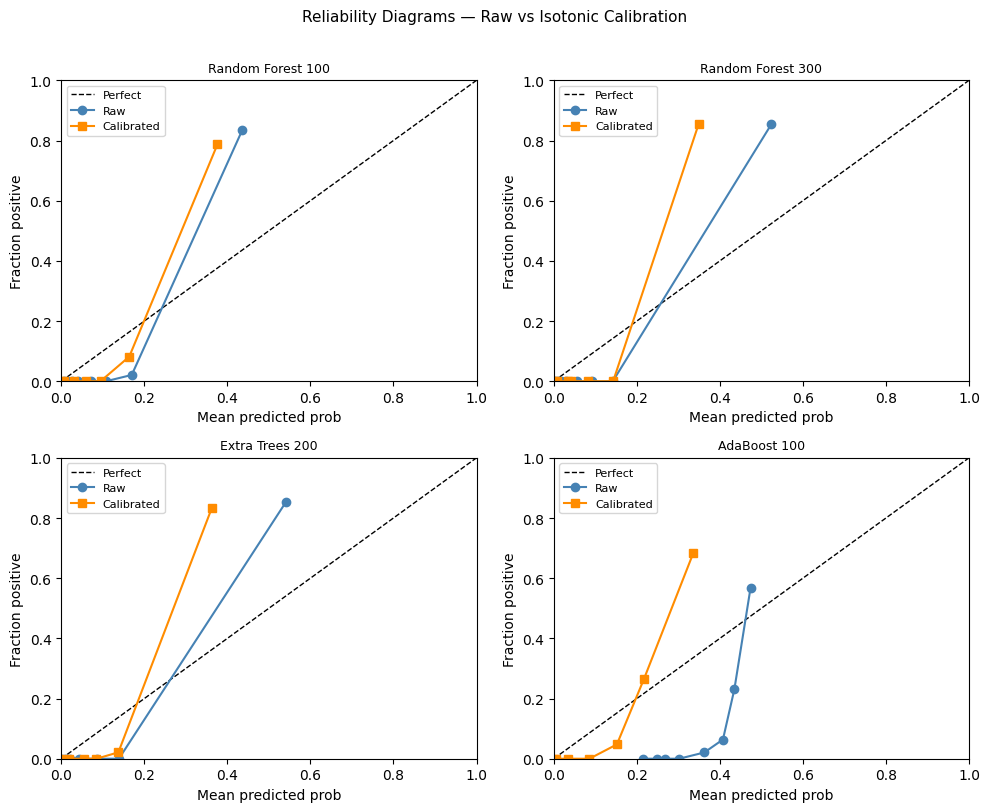


✔  Saved → calibration_curves.png
✔  Best calibrated model stored in calib_results for stacking cell.


In [12]:
# 11. PROBABILITY CALIBRATION — CalibratedClassifierCV (isotonic)
#     Tree ensembles output overconfident, poorly-spread probabilities.
#     Isotonic regression (5-fold internal CV) remaps them to true probs.
#     We compare raw vs calibrated OOF probs for the top 4 models.

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

CALIB_MODELS = [
    ('Random Forest 100',
     RandomForestClassifier(n_estimators=100, max_depth=8,
                            min_samples_leaf=3, random_state=42, n_jobs=-1)),
    ('Random Forest 300',
     RandomForestClassifier(n_estimators=300, max_depth=None,
                            min_samples_leaf=2, random_state=42, n_jobs=-1)),
    ('Extra Trees 200',
     ExtraTreesClassifier(n_estimators=200, max_depth=10,
                          min_samples_leaf=2, random_state=42, n_jobs=-1)),
    ('AdaBoost 100',
     AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=42)),
]

# Wrap each model with isotonic calibration
CALIB_MODELS_WRAPPED = [
    (name, CalibratedClassifierCV(clf, method='isotonic', cv=3))
    for name, clf in CALIB_MODELS
]

print(f"{'─'*75}")
print(f"{'Model':30s}  {'Version':14s}  {'AUC':>6}  {'Recall':>7}  {'F1':>6}")
print(f"{'─'*75}")

calib_results = []
for (name, clf_raw), (_, clf_cal) in zip(CALIB_MODELS, CALIB_MODELS_WRAPPED):
    m_raw = evaluate_with_smoteenn(name,          clf_raw, X_imp, y_raw)
    m_cal = evaluate_with_smoteenn(name+' [CAL]', clf_cal, X_imp, y_raw)
    print(f"  {name:28s}  {'raw':14s}  {m_raw['roc_auc']:.4f}  {m_raw['recall']:.4f}  {m_raw['f1_macro']:.4f}")
    print(f"  {name:28s}  {'calibrated':14s}  {m_cal['roc_auc']:.4f}  {m_cal['recall']:.4f}  {m_cal['f1_macro']:.4f}")
    print()
    calib_results.append({'model': name, 'clf_cal': clf_cal,
                          'auc_raw': m_raw['roc_auc'], 'auc_cal': m_cal['roc_auc']})

# Calibration curves (reliability diagrams)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
scaler_cal = RobustScaler()
X_sc_cal   = scaler_cal.fit_transform(X_imp)

for ax, (name, clf_raw), (_, clf_cal) in zip(axes, CALIB_MODELS, CALIB_MODELS_WRAPPED):
    # Fit on full data just to plot curves (not for evaluation)
    clf_raw_fit = sklearn_clone(clf_raw); clf_raw_fit.fit(X_sc_cal, y_raw)
    clf_cal_fit = sklearn_clone(clf_cal); clf_cal_fit.fit(X_sc_cal, y_raw)

    prob_raw = clf_raw_fit.predict_proba(X_sc_cal)[:, 1]
    prob_cal = clf_cal_fit.predict_proba(X_sc_cal)[:, 1]

    frac_r, mean_r = calibration_curve(y_raw, prob_raw, n_bins=8, strategy='quantile')
    frac_c, mean_c = calibration_curve(y_raw, prob_cal, n_bins=8, strategy='quantile')

    ax.plot([0,1],[0,1],'k--', lw=1, label='Perfect')
    ax.plot(mean_r, frac_r, 'o-', label='Raw',       color='steelblue')
    ax.plot(mean_c, frac_c, 's-', label='Calibrated', color='darkorange')
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Mean predicted prob'); ax.set_ylabel('Fraction positive')
    ax.legend(fontsize=8)
    ax.set_xlim(0,1); ax.set_ylim(0,1)

plt.suptitle('Reliability Diagrams — Raw vs Isotonic Calibration', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✔  Saved → calibration_curves.png")
print("✔  Best calibrated model stored in calib_results for stacking cell.")

In [13]:
# 12. MCC THRESHOLD OPTIMISATION
#     Matthews Correlation Coefficient — theoretically optimal for
#     imbalanced binary classification. Ranges [-1, +1]; 0 = random.
#     The model sweeps thresholds and finds: best MCC, best Recall@MCC≥0,
#     and compare to F1-macro picks from Cell 9.

from sklearn.metrics import matthews_corrcoef, confusion_matrix, classification_report
import numpy as np, pandas as pd

def sweep_with_mcc(probs, true, step=0.01):
    rows = []
    for t in np.arange(0.05, 0.96, step):
        preds = (probs >= t).astype(int)
        rows.append({
            'threshold': round(float(t), 2),
            'mcc':       matthews_corrcoef(true, preds),
            'recall':    recall_score   (true, preds, zero_division=0),
            'precision': precision_score(true, preds, zero_division=0),
            'f1_macro':  f1_score(true, preds, average='macro',  zero_division=0),
        })
    return pd.DataFrame(rows)


print("=" * 80)
print("MCC THRESHOLD TUNING — OOF probabilities · 5-fold SMOTEENN")
print("=" * 80)

mcc_rows = []
for name, clf in TOP_MODELS:
    probs, true = collect_oof_probs(name, clf, X_imp, y_raw)
    sweep       = sweep_with_mcc(probs, true)

    best_mcc_row  = sweep.loc[sweep['mcc'].idxmax()]
    # Best recall where MCC is still positive (better than random)
    eligible      = sweep[sweep['mcc'] >= 0]
    best_rec_mcc  = eligible.loc[eligible['recall'].idxmax()] if len(eligible) else best_mcc_row

    mcc_rows.append({
        'Classifier':   name,
        'BestMCC_T':    best_mcc_row['threshold'],
        'BestMCC':      round(best_mcc_row['mcc'],      4),
        'BestMCC_Rec':  round(best_mcc_row['recall'],   4),
        'BestMCC_F1':   round(best_mcc_row['f1_macro'], 4),
        'BestRec@MCC≥0_T':   best_rec_mcc['threshold'],
        'BestRec@MCC≥0':     round(best_rec_mcc['recall'], 4),
        'MCC@BestRec':       round(best_rec_mcc['mcc'],    4),
    })
    print(f"  {name:30s}  BestMCC={best_mcc_row['mcc']:.3f} T={best_mcc_row['threshold']:.2f} "
          f"Rec={best_mcc_row['recall']:.3f}  │  "
          f"BestRec(MCC≥0)={best_rec_mcc['recall']:.3f} T={best_rec_mcc['threshold']:.2f} "
          f"MCC={best_rec_mcc['mcc']:.3f}")

mcc_df = pd.DataFrame(mcc_rows).sort_values('BestMCC', ascending=False)
print(f"\n{'─'*80}")
print(mcc_df.to_string(index=False))
mcc_df.to_csv('mcc_threshold_results.csv', index=False)

# Confusion matrices for MCC winners

best_mcc_global     = mcc_df.iloc[0]
best_rec_mcc_global = mcc_df.loc[mcc_df['BestRec@MCC≥0'].idxmax()]
clf_lookup          = dict(TOP_MODELS)

def print_cm_mcc(label, name, clf, threshold):
    probs, true = collect_oof_probs(name, clf, X_imp, y_raw)
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(true, preds).ravel()
    mcc = matthews_corrcoef(true, preds)
    print(f"\n{'─'*65}")
    print(f"  {label}")
    print(f"  Model: {name}   Threshold: {threshold}   MCC: {mcc:.4f}")
    print(f"{'─'*65}")
    print(f"                    Pred: 0      Pred: 1")
    print(f"  Actual: 0 (neg)  {tn:>8d}    {fp:>8d}   ← TN / FP")
    print(f"  Actual: 1 (pos)  {fn:>8d}    {tp:>8d}   ← FN / TP\n")
    print(classification_report(true, preds,
                                 target_names=['No fQRS (0)', 'fQRS (1)'],
                                 zero_division=0))

print_cm_mcc("★  BEST MCC",
             best_mcc_global['Classifier'],
             clf_lookup[best_mcc_global['Classifier']],
             best_mcc_global['BestMCC_T'])

print_cm_mcc("★  BEST RECALL @ MCC ≥ 0",
             best_rec_mcc_global['Classifier'],
             clf_lookup[best_rec_mcc_global['Classifier']],
             best_rec_mcc_global['BestRec@MCC≥0_T'])

MCC THRESHOLD TUNING — OOF probabilities · 5-fold SMOTEENN
  LR  L1  C=0.1                   BestMCC=0.374 T=0.70 Rec=0.829  │  BestRec(MCC≥0)=1.000 T=0.05 MCC=0.202
  LR  ElasticNet                  BestMCC=0.330 T=0.61 Rec=0.756  │  BestRec(MCC≥0)=0.927 T=0.05 MCC=0.206
  LR  L2  C=1                     BestMCC=0.327 T=0.33 Rec=0.780  │  BestRec(MCC≥0)=0.854 T=0.05 MCC=0.262
  LR  L2  C=0.01                  BestMCC=0.312 T=0.61 Rec=0.878  │  BestRec(MCC≥0)=1.000 T=0.05 MCC=0.193
  Random Forest 300               BestMCC=0.419 T=0.43 Rec=0.780  │  BestRec(MCC≥0)=1.000 T=0.05 MCC=0.211
  Extra Trees 200                 BestMCC=0.383 T=0.49 Rec=0.659  │  BestRec(MCC≥0)=0.976 T=0.05 MCC=0.183
  SVM  RBF  C=10                  BestMCC=0.271 T=0.40 Rec=0.756  │  BestRec(MCC≥0)=0.902 T=0.05 MCC=0.214
  SVM  RBF  C=1                   BestMCC=0.226 T=0.60 Rec=0.732  │  BestRec(MCC≥0)=0.927 T=0.05 MCC=0.180
  Random Forest 100               BestMCC=0.414 T=0.46 Rec=0.756  │  BestRec(MCC≥0)=1

### SVM Kernel Experiments

In [14]:
# Experimenting with all different types of SVM kernels
import pandas as pd
from sklearn.svm import SVC

svm_experiments = [
    ('SVM Linear', SVC(kernel='linear', probability=True, random_state=42)),
    ('SVM Poly', SVC(kernel='poly', probability=True, random_state=42)),
    ('SVM RBF', SVC(kernel='rbf', probability=True, random_state=42)),
    ('SVM Sigmoid', SVC(kernel='sigmoid', probability=True, random_state=42))
]

svm_results = []
for name, clf in svm_experiments:
    print(f"Evaluating {name}...")
    m = evaluate_with_smoteenn(name, clf, X_imp, y_raw)
    svm_results.append({
        'Classifier': name,
        'Accuracy':  round(m['accuracy'],  4),
        'Precision': round(m['precision'], 4),
        'Recall':    round(m['recall'],    4),
        'F1_Macro':  round(m['f1_macro'],  4),
        'ROC_AUC':   round(m['roc_auc'],   4)
    })

svm_df = pd.DataFrame(svm_results)
display(svm_df.sort_values(by='F1_Macro', ascending=False))

Evaluating SVM Linear...
Evaluating SVM Poly...
Evaluating SVM RBF...
Evaluating SVM Sigmoid...


,Classifier,Accuracy,Precision,Recall,F1_Macro,ROC_AUC
0,SVM Linear,0.7616,0.2350,0.5111,0.5847,0.7827
2,SVM RBF,0.3638,0.1446,1.0000,0.3493,0.7304
3,SVM Sigmoid,0.3455,0.1409,1.0000,0.3341,0.7553
1,SVM Poly,0.3403,0.1400,1.0000,0.3297,0.6921


### Model Stacking

In [15]:
# 13. STACKING — OOF meta-features from top 4 base models
#     Base learners: RF100, RF300, AdaBoost100, ExtraTrees200
#     Meta-learner : LogisticRegression (L2) on OOF probs
#     Outer loop   : same 5-fold SMOTEENN (no leakage)
#     Inner loop   : base models trained on inner folds to generate
#                    OOF probs for meta-learner training

from sklearn.base import clone as sklearn_clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score

STACK_BASE = [
    ('RF100',    RandomForestClassifier(n_estimators=100, max_depth=8,
                                        min_samples_leaf=3, random_state=42, n_jobs=-1)),
    ('RF300',    RandomForestClassifier(n_estimators=300, max_depth=None,
                                        min_samples_leaf=2, random_state=42, n_jobs=-1)),
    ('ET200',    ExtraTreesClassifier(n_estimators=200, max_depth=10,
                                      min_samples_leaf=2, random_state=42, n_jobs=-1)),
    ('AdaB100',  AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=42)),
]
META_CLF = LogisticRegression(C=1.0, penalty='l2', solver='lbfgs',
                               max_iter=2000, random_state=42)

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler_st = RobustScaler()

oof_meta_p = np.zeros(len(y_raw))   # stacked OOF probs
oof_meta_y = np.zeros(len(y_raw), dtype=int)

fold_aucs, fold_recs, fold_f1s = [], [], []

for fold, (tr_idx, val_idx) in enumerate(outer_cv.split(X_imp, y_raw)):
    X_tr,  X_val  = X_imp[tr_idx],  X_imp[val_idx]
    y_tr,  y_val  = y_raw[tr_idx],  y_raw[val_idx]

    X_tr_sc  = scaler_st.fit_transform(X_tr)
    X_val_sc = scaler_st.transform(X_val)

    # Inner loop: generate OOF probs for meta-learner training
    inner_cv    = StratifiedKFold(n_splits=4, shuffle=True, random_state=42 + fold)
    meta_train  = np.zeros((len(y_tr), len(STACK_BASE)))

    for b_idx, (bname, bclf) in enumerate(STACK_BASE):
        for itr_idx, ival_idx in inner_cv.split(X_tr_sc, y_tr):
            X_itr, X_ival = X_tr_sc[itr_idx], X_tr_sc[ival_idx]
            y_itr, y_ival = y_tr[itr_idx],    y_tr[ival_idx]
            X_res, y_res  = smoteenn(X_itr, y_itr, random_state=42 + fold)
            bc = sklearn_clone(bclf); bc.fit(X_res, y_res)
            meta_train[ival_idx, b_idx] = bc.predict_proba(X_ival)[:, 1]

    # Train meta-learner on inner OOF probs
    meta_clf = sklearn_clone(META_CLF)
    meta_clf.fit(meta_train, y_tr)

    # Generate base-model probs on outer val set
    meta_val = np.zeros((len(y_val), len(STACK_BASE)))
    X_tr_sm, y_tr_sm = smoteenn(X_tr_sc, y_tr, random_state=42 + fold)
    for b_idx, (bname, bclf) in enumerate(STACK_BASE):
        bc = sklearn_clone(bclf); bc.fit(X_tr_sm, y_tr_sm)
        meta_val[:, b_idx] = bc.predict_proba(X_val_sc)[:, 1]

    # Meta-learner prediction
    stack_prob = meta_clf.predict_proba(meta_val)[:, 1]
    stack_pred = (stack_prob >= 0.5).astype(int)

    oof_meta_p[val_idx] = stack_prob
    oof_meta_y[val_idx] = y_val

    fold_aucs.append(roc_auc_score(y_val, stack_prob))
    fold_recs.append(recall_score (y_val, stack_pred, zero_division=0))
    fold_f1s .append(f1_score     (y_val, stack_pred, average='macro', zero_division=0))
    print(f"  Fold {fold+1}  AUC={fold_aucs[-1]:.4f}  Recall={fold_recs[-1]:.4f}  F1={fold_f1s[-1]:.4f}")

print(f"\n{'='*55}")
print(f"  STACK  AUC  = {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"  STACK  Rec  = {np.mean(fold_recs):.4f} ± {np.std(fold_recs):.4f}")
print(f"  STACK  F1   = {np.mean(fold_f1s ):.4f} ± {np.std(fold_f1s ):.4f}")
print(f"{'='*55}")

# Threshold tuning on stacked OOF probs
stack_sweep   = sweep_with_mcc(oof_meta_p, oof_meta_y)
best_mcc_st   = stack_sweep.loc[stack_sweep['mcc'].idxmax()]
best_f1_st    = stack_sweep.loc[stack_sweep['f1_macro'].idxmax()]
eligible_st   = stack_sweep[stack_sweep['mcc'] >= 0]
best_rec_st   = eligible_st.loc[eligible_st['recall'].idxmax()]

print(f"\n  Stack BestF1  T={best_f1_st['threshold']:.2f}  F1={best_f1_st['f1_macro']:.4f}  Rec={best_f1_st['recall']:.4f}")
print(f"  Stack BestMCC T={best_mcc_st['threshold']:.2f}  MCC={best_mcc_st['mcc']:.4f}  Rec={best_mcc_st['recall']:.4f}")
print(f"  Stack BestRec@MCC≥0 T={best_rec_st['threshold']:.2f}  Rec={best_rec_st['recall']:.4f}  MCC={best_rec_st['mcc']    :.4f}")

  Fold 1  AUC=0.8152  Recall=0.0000  F1=0.4726
  Fold 2  AUC=0.9395  Recall=0.0000  F1=0.4690
  Fold 3  AUC=0.7849  Recall=0.0000  F1=0.4722
  Fold 4  AUC=0.7335  Recall=0.0000  F1=0.4685
  Fold 5  AUC=0.8493  Recall=0.0000  F1=0.4722

  STACK  AUC  = 0.8245 ± 0.0690
  STACK  Rec  = 0.0000 ± 0.0000
  STACK  F1   = 0.4709 ± 0.0018

  Stack BestF1  T=0.20  F1=0.6680  Rec=0.5854
  Stack BestMCC T=0.13  MCC=0.3989  Rec=0.8049
  Stack BestRec@MCC≥0 T=0.05  Rec=0.9512  MCC=0.2699


### Repeated Stratified CV

In [16]:
# 14. REPEATED STRATIFIED CV — 10 × 5-fold
#     With N=382, single-run 5-fold has high variance. Repeating 10×
#     with different random seeds gives stable mean ± std estimates.
#     Run on top 5 models only (time-bounded). Prints ranked table.

N_REPEATS = 10
N_SPLITS  = 5

TOP5 = [
    ('Random Forest 100',
     RandomForestClassifier(n_estimators=100, max_depth=8,
                            min_samples_leaf=3, random_state=42, n_jobs=-1)),
    ('Random Forest 300',
     RandomForestClassifier(n_estimators=300, max_depth=None,
                            min_samples_leaf=2, random_state=42, n_jobs=-1)),
    ('Extra Trees 200',
     ExtraTreesClassifier(n_estimators=200, max_depth=10,
                          min_samples_leaf=2, random_state=42, n_jobs=-1)),
    ('AdaBoost 100',
     AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=42)),
    ('LR L1 C=0.1',
     LogisticRegression(C=0.1, penalty='l1', solver='liblinear',
                        max_iter=2000, random_state=42)),
]

rep_results = {name: {'auc':[], 'recall':[], 'f1':[], 'mcc':[]} for name, _ in TOP5}

for repeat in range(N_REPEATS):
    seed = 100 + repeat * 13     # different seed each repeat
    cv   = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    sc   = RobustScaler()

    for name, clf in TOP5:
        fold_p, fold_y = np.zeros(len(y_raw)), np.zeros(len(y_raw), dtype=int)
        for fold, (tr_idx, val_idx) in enumerate(cv.split(X_imp, y_raw)):
            X_tr,  X_val  = X_imp[tr_idx],  X_imp[val_idx]
            y_tr,  y_val  = y_raw[tr_idx],  y_raw[val_idx]
            X_tr_sc  = sc.fit_transform(X_tr)
            X_val_sc = sc.transform(X_val)
            X_res, y_res = smoteenn(X_tr_sc, y_tr, random_state=seed + fold)
            c = sklearn_clone(clf); c.fit(X_res, y_res)
            fold_p[val_idx] = c.predict_proba(X_val_sc)[:, 1] \
                if hasattr(c, 'predict_proba') else c.decision_function(X_val_sc)
            fold_y[val_idx] = y_val

        preds = (fold_p >= 0.5).astype(int)
        rep_results[name]['auc'   ].append(roc_auc_score(fold_y, fold_p))
        rep_results[name]['recall'].append(recall_score (fold_y, preds, zero_division=0))
        rep_results[name]['f1'    ].append(f1_score     (fold_y, preds, average='macro', zero_division=0))
        rep_results[name]['mcc'   ].append(matthews_corrcoef(fold_y, preds))

    print(f"  Repeat {repeat+1:2d}/{N_REPEATS} done")

# Summary table

print(f"\n{'='*95}")
print(f"REPEATED CV RESULTS  ({N_REPEATS} × {N_SPLITS}-fold)  — mean ± std  (std reflects true sampling variance)")
print(f"{'='*95}")
print(f"{'Model':30s}  {'AUC':^14}  {'Recall':^14}  {'F1-macro':^14}  {'MCC':^14}")
print(f"{'─'*95}")

rep_rows = []
for name, _ in TOP5:
    d = rep_results[name]
    row = {
        'Classifier':  name,
        'AUC_mean':    np.mean(d['auc']),    'AUC_std':    np.std(d['auc']),
        'Rec_mean':    np.mean(d['recall']), 'Rec_std':    np.std(d['recall']),
        'F1_mean':     np.mean(d['f1']),     'F1_std':     np.std(d['f1']),
        'MCC_mean':    np.mean(d['mcc']),    'MCC_std':    np.std(d['mcc']),
    }
    rep_rows.append(row)
    print(f"  {name:28s}  "
          f"{row['AUC_mean']:.4f}±{row['AUC_std']:.4f}  "
          f"{row['Rec_mean']:.4f}±{row['Rec_std']:.4f}  "
          f"{row['F1_mean']:.4f}±{row['F1_std']:.4f}  "
          f"{row['MCC_mean']:.4f}±{row['MCC_std']:.4f}")

rep_df = pd.DataFrame(rep_rows).sort_values('AUC_mean', ascending=False)
rep_df.to_csv('repeated_cv_results.csv', index=False)
print(f"\n✔  Saved → repeated_cv_results.csv")
print(f"\n  Best stable AUC  : {rep_df.iloc[0]['Classifier']}  "
      f"{rep_df.iloc[0]['AUC_mean']:.4f} ± {rep_df.iloc[0]['AUC_std']:.4f}")
print(f"  Best stable MCC  : {rep_df.loc[rep_df['MCC_mean'].idxmax()]['Classifier']}  "
      f"{rep_df.loc[rep_df['MCC_mean'].idxmax()]['MCC_mean']:.4f} ± "
      f"{rep_df.loc[rep_df['MCC_mean'].idxmax()]['MCC_std']:.4f}")

  Repeat  1/10 done
  Repeat  2/10 done
  Repeat  3/10 done
  Repeat  4/10 done
  Repeat  5/10 done
  Repeat  6/10 done
  Repeat  7/10 done
  Repeat  8/10 done
  Repeat  9/10 done
  Repeat 10/10 done

REPEATED CV RESULTS  (10 × 5-fold)  — mean ± std  (std reflects true sampling variance)
Model                                AUC            Recall         F1-macro          MCC      
───────────────────────────────────────────────────────────────────────────────────────────────
  Random Forest 100             0.8243±0.0139  0.6317±0.0561  0.6407±0.0161  0.3317±0.0379
  Random Forest 300             0.8290±0.0131  0.5902±0.0405  0.6438±0.0148  0.3250±0.0312
  Extra Trees 200               0.8163±0.0117  0.6366±0.0550  0.6425±0.0226  0.3357±0.0455
  AdaBoost 100                  0.7879±0.0156  0.5610±0.0636  0.6045±0.0154  0.2605±0.0393
  LR L1 C=0.1                   0.7946±0.0212  0.9122±0.0348  0.5163±0.0086  0.2887±0.0189

✔  Saved → repeated_cv_results.csv

  Best stable AUC  : Random 

### Final Best Single Model

In [17]:
# 15. FINAL MODEL: ET200 on SFM-selected 30 features
#     Threshold tuned by MCC (best balance), F1, and Recall
#     X_selected was set in Cell 10 as the SFM 30-feature subset

print("=" * 70)
print("FINAL MODEL — Extra Trees 200 on SFM (30 features)")
print("=" * 70)

ET_FINAL = ExtraTreesClassifier(
    n_estimators=200, max_depth=10,
    min_samples_leaf=2, random_state=42, n_jobs=-1
)

# OOF probs on X_selected
et_probs, et_true = collect_oof_probs(
    'ET200_SFM', ET_FINAL, X_selected, y_raw
)

# Full sweep: MCC, F1, Recall
et_sweep = sweep_with_mcc(et_probs, et_true, step=0.01)

best_mcc_et  = et_sweep.loc[et_sweep['mcc'].idxmax()]
best_f1_et   = et_sweep.loc[et_sweep['f1_macro'].idxmax()]
eligible_et  = et_sweep[et_sweep['mcc'] >= 0]
best_rec_et  = eligible_et.loc[eligible_et['recall'].idxmax()]

print(f"\n  Metric     Threshold    MCC      Recall   Precision   F1-macro")
print(f"  {'─'*60}")
for label, row in [('Best MCC ', best_mcc_et),
                   ('Best F1  ', best_f1_et),
                   ('Best Rec ', best_rec_et)]:
    print(f"  {label}    T={row['threshold']:.2f}       "
          f"{row['mcc']:.4f}   {row['recall']:.4f}   "
          f"{row['precision']:.4f}      {row['f1_macro']:.4f}")

# Compare to ET200 on full features (from Cell 12)
et_full_probs, et_full_true = collect_oof_probs(
    'ET200_full', ExtraTreesClassifier(
        n_estimators=200, max_depth=10,
        min_samples_leaf=2, random_state=42, n_jobs=-1),
    X_imp, y_raw
)
et_full_sweep = sweep_with_mcc(et_full_probs, et_full_true)
et_full_best  = et_full_sweep.loc[et_full_sweep['mcc'].idxmax()]

print(f"\n  {'─'*60}")
print(f"  ET200 full (111 feat)  T={et_full_best['threshold']:.2f}  "
      f"MCC={et_full_best['mcc']:.4f}  Rec={et_full_best['recall']:.4f}")
print(f"  ET200 SFM  (30 feat)   T={best_mcc_et['threshold']:.2f}  "
      f"MCC={best_mcc_et['mcc']:.4f}  Rec={best_mcc_et['recall']:.4f}  "
      f"← {'better' if best_mcc_et['mcc'] > et_full_best['mcc'] else '⚠ check'}")

# Confusion matrix at best MCC
preds_mcc = (et_probs >= best_mcc_et['threshold']).astype(int)
tn,fp,fn,tp = confusion_matrix(et_true, preds_mcc).ravel()

print(f"\n{'─'*65}")
print(f"  ET200 + SFM @ T={best_mcc_et['threshold']:.2f}  (Best MCC = {best_mcc_et['mcc']:.4f})")
print(f"{'─'*65}")
print(f"                    Pred: 0      Pred: 1")
print(f"  Actual: 0 (neg)  {tn:>8d}    {fp:>8d}   ← TN / FP")
print(f"  Actual: 1 (pos)  {fn:>8d}    {tp:>8d}   ← FN / TP\n")
print(classification_report(et_true, preds_mcc,
                             target_names=['No fQRS (0)', 'fQRS (1)'],
                             zero_division=0))

# Store for portfolio cell
ET_FINAL_PROBS = et_probs
ET_FINAL_TRUE  = et_true
ET_FINAL_SWEEP = et_sweep
print("✔  ET_FINAL_PROBS / ET_FINAL_SWEEP stored for Cell 16.")

FINAL MODEL — Extra Trees 200 on SFM (30 features)

  Metric     Threshold    MCC      Recall   Precision   F1-macro
  ────────────────────────────────────────────────────────────
  Best MCC     T=0.55       0.4367   0.7317   0.3659      0.6948
  Best F1      T=0.55       0.4367   0.7317   0.3659      0.6948
  Best Rec     T=0.05       0.2462   0.9756   0.1653      0.4303

  ────────────────────────────────────────────────────────────
  ET200 full (111 feat)  T=0.49  MCC=0.3827  Rec=0.6585
  ET200 SFM  (30 feat)   T=0.55  MCC=0.4367  Rec=0.7317  ← better

─────────────────────────────────────────────────────────────────
  ET200 + SFM @ T=0.55  (Best MCC = 0.4367)
─────────────────────────────────────────────────────────────────
                    Pred: 0      Pred: 1
  Actual: 0 (neg)       289          52   ← TN / FP
  Actual: 1 (pos)        11          30   ← FN / TP

              precision    recall  f1-score   support

 No fQRS (0)       0.96      0.85      0.90       341
    fQR

# CLINICAL DECISION PORTFOLIO STACKING + ENSEMBLING METHODOLOGY EXPERIMENTS

In [18]:
# ─────────────────────────────────────────────────────────────────
# 16. CLINICAL DECISION PORTFOLIO
#     One model (ET200 + SFM), three clinically-defined thresholds.
#
#  SCREENER   → maximise recall, MCC must stay ≥ 0
#               "Do not miss any fQRS patient"
#
#  GATEKEEPER → maximise MCC (best balanced discrimination)
#               "Clinical decision support for further workup"
#
#  CONFIRMER  → maximise precision s.t. recall ≥ 0.50
#               "Trigger only when confident; avoids unnecessary procedures"
#
#  Each profile prints: threshold, full metrics, confusion matrix,
#  and a plain-English clinical interpretation.
# ─────────────────────────────────────────────────────────────────

from sklearn.metrics import (confusion_matrix, classification_report,
                              matthews_corrcoef, roc_auc_score)
import numpy as np

probs = ET_FINAL_PROBS
true  = ET_FINAL_TRUE
sweep = ET_FINAL_SWEEP     # precomputed in Cell 15

# Define the three profiles

# SCREENER: best recall where MCC ≥ 0
screener_pool = sweep[sweep['mcc'] >= 0]
screener_row  = screener_pool.loc[screener_pool['recall'].idxmax()]

# GATEKEEPER: best MCC
gatekeeper_row = sweep.loc[sweep['mcc'].idxmax()]

# CONFIRMER: best precision where recall ≥ 0.50
confirmer_pool = sweep[sweep['recall'] >= 0.50]
confirmer_row  = confirmer_pool.loc[confirmer_pool['precision'].idxmax()] \
                 if len(confirmer_pool) else sweep.loc[sweep['precision'].idxmax()]

PROFILES = [
    ('SCREENER',    screener_row,   '', 'Maximise recall — miss as few fQRS patients as possible'),
    ('GATEKEEPER',  gatekeeper_row, '', 'Best MCC — balanced decision support for further workup'),
    ('CONFIRMER',   confirmer_row,  '', 'Maximise precision (recall ≥ 50%) — flag only when confident'),
]

# Print summary card

print("=" * 75)
print("CLINICAL DECISION PORTFOLIO — ET200 + SFM (30 features)")
print("=" * 75)
print(f"\n  {'Profile':14s}  {'T':>5}  {'Recall':>7}  {'Precision':>10}  "
      f"{'F1-macro':>9}  {'MCC':>7}  {'Specificity':>12}")
print(f"  {'─'*73}")

profile_metrics = {}
for name, row, icon, desc in PROFILES:
    t     = row['threshold']
    preds = (probs >= t).astype(int)
    tn, fp, fn, tp_v = confusion_matrix(true, preds).ravel()
    spec  = tn / (tn + fp)
    mcc   = matthews_corrcoef(true, preds)
    rec   = tp_v / (tp_v + fn)
    prec  = tp_v / (tp_v + fp) if (tp_v + fp) > 0 else 0
    f1    = row['f1_macro']
    profile_metrics[name] = dict(t=t, tn=tn, fp=fp, fn=fn, tp=tp_v,
                                  spec=spec, mcc=mcc, rec=rec, prec=prec, f1=f1)
    print(f"  {icon} {name:12s}  {t:>5.2f}  {rec:>7.4f}  {prec:>10.4f}  "
          f"{f1:>9.4f}  {mcc:>7.4f}  {spec:>12.4f}")

print(f"\n  {'─'*73}")
print(f"  (All profiles use the same ET200+SFM model — only threshold differs)\n")

# Detailed confusion matrix per profile

for name, row, icon, desc in PROFILES:
    m = profile_metrics[name]
    total_pos = m['tp'] + m['fn']   # always 41
    total_neg = m['tn'] + m['fp']   # always 341

    caught_pct  = m['tp'] / total_pos * 100
    missed_pct  = m['fn'] / total_pos * 100
    flagged_neg = m['fp']
    cleared_neg = m['tn']

    print(f"\n{'═'*65}")
    print(f"  {icon}  {name}   (Threshold = {m['t']:.2f})")
    print(f"  {desc}")
    print(f"{'─'*65}")
    print(f"                    Pred: 0      Pred: 1")
    print(f"  Actual: 0 (neg)  {m['tn']:>8d}    {m['fp']:>8d}   ← TN / FP")
    print(f"  Actual: 1 (pos)  {m['fn']:>8d}    {m['tp']:>8d}   ← FN / TP")
    print(f"{'─'*65}")
    print(f"  Of {total_pos} fQRS patients  : {m['tp']} caught ({caught_pct:.1f}%), "
          f"{m['fn']} missed ({missed_pct:.1f}%)")
    print(f"  Of {total_neg} healthy patients: {cleared_neg} correctly cleared, "
          f"{flagged_neg} sent for unnecessary follow-up")
    print(f"  MCC={m['mcc']:.4f}   Specificity={m['spec']:.4f}")
    print()
    print(classification_report(true, (probs >= m['t']).astype(int),
                                 target_names=['No fQRS (0)', 'fQRS (1)'],
                                 zero_division=0))

# Side-by-side clinical trade-off summary

print(f"\n{'═'*75}")
print("  CLINICAL TRADE-OFF SUMMARY")
print(f"{'─'*75}")
print(f"  {'Profile':14s}  {'fQRS caught':>12}  {'fQRS missed':>12}  "
      f"{'Healthy flagged':>16}  {'Healthy cleared':>16}")
print(f"  {'─'*73}")
for name, row, icon, desc in PROFILES:
    m = profile_metrics[name]
    print(f"  {icon} {name:12s}  "
          f"{m['tp']:>5d} / 41 ({m['tp']/41*100:4.1f}%)  "
          f"{m['fn']:>5d} / 41 ({m['fn']/41*100:4.1f}%)  "
          f"{m['fp']:>8d} / 341 ({m['fp']/341*100:4.1f}%)  "
          f"{m['tn']:>8d} / 341 ({m['tn']/341*100:4.1f}%)")
print(f"{'═'*75}")

CLINICAL DECISION PORTFOLIO — ET200 + SFM (30 features)

  Profile             T   Recall   Precision   F1-macro      MCC   Specificity
  ─────────────────────────────────────────────────────────────────────────
   SCREENER       0.05   0.9756      0.1653     0.4303   0.2462        0.4076
   GATEKEEPER     0.55   0.7317      0.3659     0.6948   0.4367        0.8475
   CONFIRMER      0.64   0.5610      0.3966     0.6925   0.3953        0.8974

  ─────────────────────────────────────────────────────────────────────────
  (All profiles use the same ET200+SFM model — only threshold differs)


═════════════════════════════════════════════════════════════════
    SCREENER   (Threshold = 0.05)
  Maximise recall — miss as few fQRS patients as possible
─────────────────────────────────────────────────────────────────
                    Pred: 0      Pred: 1
  Actual: 0 (neg)       139         202   ← TN / FP
  Actual: 1 (pos)         1          40   ← FN / TP
───────────────────────────────────

In [19]:
# 17. XGBOOST + LIGHTGBM — native imbalance handling
#     These were absent from the original benchmark.
#     scale_pos_weight (XGB) / is_unbalance (LGBM) handle the
#     10.7% minority class without needing SMOTEENN.
#     We test: (a) with SMOTEENN, (b) with native weighting only
#     on both full (111) and SFM (30) features.

import subprocess, sys

for pkg in ['xgboost', 'lightgbm']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import xgboost as xgb
import lightgbm as lgb

pos_weight = (y_raw == 0).sum() / (y_raw == 1).sum()   # ≈ 8.3

BOOST_MODELS = [
    # XGBoost variants
    ('XGB scale_pos_weight',
     xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8,
                        scale_pos_weight=pos_weight,
                        eval_metric='logloss', use_label_encoder=False,
                        random_state=42, n_jobs=-1, verbosity=0)),
    ('XGB no_weight',
     xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8,
                        eval_metric='logloss', use_label_encoder=False,
                        random_state=42, n_jobs=-1, verbosity=0)),
    # LightGBM variants
    ('LGBM is_unbalance',
     lgb.LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8,
                         is_unbalance=True, random_state=42,
                         n_jobs=-1, verbose=-1)),
    ('LGBM scale_pos_weight',
     lgb.LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8,
                         scale_pos_weight=pos_weight, random_state=42,
                         n_jobs=-1, verbose=-1)),
    ('LGBM no_weight',
     lgb.LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8,
                         random_state=42, n_jobs=-1, verbose=-1)),
]

print("=" * 80)
print(f"XGBOOST + LIGHTGBM — pos_weight={pos_weight:.2f} (neg/pos ratio)")
print("=" * 80)
print(f"\n  {'Model':30s}  {'Features':12s}  {'AUC':>6}  {'Recall':>7}  {'F1':>6}  {'MCC':>6}")
print(f"  {'─'*75}")

boost_results = []
for name, clf in BOOST_MODELS:
    for feat_label, X_use in [('Full (111)', X_imp), ('SFM (30)',  X_selected)]:
        m = evaluate_with_smoteenn(name, clf, X_use, y_raw)

        # Also get OOF probs for MCC sweep
        probs_b, true_b = collect_oof_probs(name + feat_label, clf, X_use, y_raw)
        sweep_b  = sweep_with_mcc(probs_b, true_b)
        best_mcc_b = sweep_b.loc[sweep_b['mcc'].idxmax()]

        print(f"  {name:30s}  {feat_label:12s}  "
              f"{m['roc_auc']:.4f}  {m['recall']:.4f}  "
              f"{m['f1_macro']:.4f}  {best_mcc_b['mcc']:.4f}")

        boost_results.append({
            'Model': name, 'Features': feat_label,
            'AUC': round(m['roc_auc'], 4),
            'Recall': round(m['recall'], 4),
            'F1': round(m['f1_macro'], 4),
            'BestMCC': round(best_mcc_b['mcc'], 4),
            'BestMCC_T': best_mcc_b['threshold'],
            'BestMCC_Rec': round(best_mcc_b['recall'], 4),
            '_probs': probs_b, '_true': true_b,
        })

boost_df = pd.DataFrame(boost_results).drop(columns=['_probs','_true'])
boost_df.to_csv('boost_results.csv', index=False)

# Compare best booster vs current champion
champion_mcc = 0.4367   # ET200 + SFM
best_boost   = boost_df.loc[boost_df['BestMCC'].idxmax()]

print(f"\n  {'─'*75}")
print(f"  Current champion  ET200+SFM         MCC={champion_mcc:.4f}")
print(f"  Best booster      {best_boost['Model']:18s} {best_boost['Features']:12s}  "
      f"MCC={best_boost['BestMCC']:.4f}  "
      f"{'new champion' if best_boost['BestMCC'] > champion_mcc else '⚠ no improvement'}")

# Store best booster probs for portfolio update
best_idx = boost_df['BestMCC'].idxmax()
BOOST_BEST_PROBS = boost_results[best_idx]['_probs']
BOOST_BEST_TRUE  = boost_results[best_idx]['_true']
BOOST_BEST_NAME  = best_boost['Model'] + ' ' + best_boost['Features']
print(f"\n✔  BOOST_BEST_PROBS stored ({BOOST_BEST_NAME})")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


XGBOOST + LIGHTGBM — pos_weight=8.32 (neg/pos ratio)

  Model                           Features         AUC   Recall      F1     MCC
  ───────────────────────────────────────────────────────────────────────────
  XGB scale_pos_weight            Full (111)    0.8107  0.6778  0.6528  0.4035
  XGB scale_pos_weight            SFM (30)      0.8160  0.6528  0.6466  0.3567
  XGB no_weight                   Full (111)    0.8234  0.5806  0.6651  0.3891
  XGB no_weight                   SFM (30)      0.8348  0.5306  0.6401  0.3645
  LGBM is_unbalance               Full (111)    0.8033  0.5333  0.6452  0.3928
  LGBM is_unbalance               SFM (30)      0.8088  0.4806  0.6209  0.3124
  LGBM scale_pos_weight           Full (111)    0.8111  0.7028  0.6767  0.3992
  LGBM scale_pos_weight           SFM (30)      0.8141  0.6028  0.6390  0.3683
  LGBM no_weight                  Full (111)    0.8065  0.5083  0.6385  0.3981
  LGBM no_weight                  SFM (30)      0.8073  0.5278  0.6303  0.352

In [20]:
# 18. OPTUNA BAYESIAN HYPERPARAMETER SEARCH — ET200 + SFM
#     Searches over 8 hyperparameters simultaneously.
#     Objective: maximise mean OOF MCC across 5-fold SMOTEENN CV.
#     n_trials=60 gives good coverage without excessive runtime.
#     Also runs the same search on the best booster from Cell 17.

subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'optuna', '-q'])
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def smoteenn_mcc_cv(clf, X, y, n_splits=5, seed=42):
    """Returns mean OOF MCC at default threshold 0.5."""
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    sc = RobustScaler()
    all_p, all_y = np.zeros(len(y)), np.zeros(len(y), dtype=int)
    for fold, (tr, val) in enumerate(cv.split(X, y)):
        Xtr_s = sc.fit_transform(X[tr]); Xval_s = sc.transform(X[val])
        Xr, yr = smoteenn(Xtr_s, y[tr], random_state=seed+fold)
        c = sklearn_clone(clf); c.fit(Xr, yr)
        all_p[val] = c.predict_proba(Xval_s)[:, 1]
        all_y[val] = y[val]
    # Use best-threshold MCC, not 0.5
    sweep = sweep_with_mcc(all_p, all_y, step=0.02)
    return sweep['mcc'].max()

# A. ET on SFM

def et_objective(trial):
    clf = ExtraTreesClassifier(
        n_estimators      = trial.suggest_int  ('n_estimators',    100, 600, step=50),
        max_depth         = trial.suggest_int  ('max_depth',        3,  20),
        min_samples_leaf  = trial.suggest_int  ('min_samples_leaf', 1,  10),
        min_samples_split = trial.suggest_int  ('min_samples_split',2,  20),
        max_features      = trial.suggest_float('max_features',    0.3,  1.0),
        bootstrap         = trial.suggest_categorical('bootstrap', [True, False]),
        random_state=42, n_jobs=-1
    )
    return smoteenn_mcc_cv(clf, X_selected, y_raw)

print("Tuning ET200+SFM …  (60 trials, ~3-5 min)")
study_et = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_et.optimize(et_objective, n_trials=60, show_progress_bar=False)

best_et_params = study_et.best_params
best_et_mcc    = study_et.best_value
print(f"  Best ET MCC = {best_et_mcc:.4f}  (vs baseline 0.4367)")
print(f"  Params: {best_et_params}")

# B. LGBM on SFM (if it beat ET in Cell 17)

def lgbm_objective(trial):
    clf = lgb.LGBMClassifier(
        n_estimators     = trial.suggest_int  ('n_estimators',   100, 600, step=50),
        max_depth        = trial.suggest_int  ('max_depth',        3,  10),
        learning_rate    = trial.suggest_float('learning_rate',  0.01, 0.2, log=True),
        num_leaves       = trial.suggest_int  ('num_leaves',      15,  63),
        min_child_samples= trial.suggest_int  ('min_child_samples',5,  30),
        subsample        = trial.suggest_float('subsample',       0.5,  1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree',0.5,  1.0),
        scale_pos_weight = pos_weight,
        random_state=42, n_jobs=-1, verbose=-1
    )
    return smoteenn_mcc_cv(clf, X_selected, y_raw)

print("\nTuning LGBM+SFM …  (60 trials, ~2-4 min)")
study_lgbm = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=42))
study_lgbm.optimize(lgbm_objective, n_trials=60, show_progress_bar=False)

best_lgbm_params = study_lgbm.best_params
best_lgbm_mcc    = study_lgbm.best_value
print(f"  Best LGBM MCC = {best_lgbm_mcc:.4f}")
print(f"  Params: {best_lgbm_params}")

# C. Full eval of tuned winners

print(f"\n{'='*70}")
print("TUNED MODEL EVALUATION — full SMOTEENN 5-fold CV + threshold sweep")
print(f"{'='*70}")

TUNED = [
    ('ET_tuned+SFM',
     ExtraTreesClassifier(**best_et_params, random_state=42, n_jobs=-1),
     X_selected),
    ('LGBM_tuned+SFM',
     lgb.LGBMClassifier(**best_lgbm_params, scale_pos_weight=pos_weight,
                         random_state=42, n_jobs=-1, verbose=-1),
     X_selected),
]

for name, clf, X_use in TUNED:
    probs_t, true_t = collect_oof_probs(name, clf, X_use, y_raw)
    sweep_t  = sweep_with_mcc(probs_t, true_t)
    best_t   = sweep_t.loc[sweep_t['mcc'].idxmax()]
    preds_t  = (probs_t >= best_t['threshold']).astype(int)
    tn,fp,fn,tp_v = confusion_matrix(true_t, preds_t).ravel()

    print(f"\n  {name}  T={best_t['threshold']:.2f}  "
          f"MCC={best_t['mcc']:.4f}  Rec={best_t['recall']:.4f}  "
          f"F1={best_t['f1_macro']:.4f}")
    print(f"  {'─'*55}")
    print(f"                    Pred: 0      Pred: 1")
    print(f"  Actual: 0 (neg)  {tn:>8d}    {fp:>8d}")
    print(f"  Actual: 1 (pos)  {fn:>8d}    {tp_v:>8d}")
    print()
    print(classification_report(true_t, preds_t,
                                 target_names=['No fQRS','fQRS'],
                                 zero_division=0))

print(f"\n{'='*70}")
print(f"  Baseline  ET200+SFM (manual HPs)  MCC=0.4367")
print(f"  Tuned ET  +SFM                    MCC={best_et_mcc:.4f}  "
      f"{'✅' if best_et_mcc > 0.4367 else '—'}")
print(f"  Tuned LGBM+SFM                    MCC={best_lgbm_mcc:.4f}  "
      f"{'✅' if best_lgbm_mcc > 0.4367 else '—'}")
print(f"{'='*70}")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Tuning ET200+SFM …  (60 trials, ~3-5 min)
  Best ET MCC = 0.4232  (vs baseline 0.4367)
  Params: {'n_estimators': 200, 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 19, 'max_features': 0.35403963812262723, 'bootstrap': False}

Tuning LGBM+SFM …  (60 trials, ~2-4 min)
  Best LGBM MCC = 0.4025
  Params: {'n_estimators': 250, 'max_depth': 4, 'learning_rate': 0.04660148593493794, 'num_leaves': 20, 'min_child_samples': 29, 'subsample': 0.5603783899757546, 'colsample_bytree': 0.9845994544906669}

TUNED MODEL EVALUATION — full SMOTEENN 5-fold CV + threshold sweep

  ET_tuned+SFM  T=0.69  MCC=0.4232  Rec=0.6341  F1=0.7011
  ───────────────────────────────────────────────────────
                    Pred: 0      Pred: 1
  Actual: 0 (neg)       301          40
  Actual: 1 (pos)        15          26

              precision    recall  f1-score   support

     No fQRS       0.95      0.88      0.92       341
        fQRS       0.39      0.63      0.49        41

    accuracy        

### SHAP FEATURE AUDIT

In [21]:
# ─────────────────────────────────────────────────────────────────
# 19. SHAP FEATURE AUDIT — ET200 + SFM (fixed)
# ─────────────────────────────────────────────────────────────────

import shap, matplotlib, matplotlib.pyplot as plt, warnings
import numpy as np, pandas as pd
matplotlib.use('Agg')
warnings.filterwarnings('ignore')

# ── Fit on full dataset (SHAP only) ──────────────────────────────
scaler_shap = RobustScaler()
X_shap_sc   = scaler_shap.fit_transform(X_selected)

et_shap = ExtraTreesClassifier(
    n_estimators=200, max_depth=10,
    min_samples_leaf=2, random_state=42, n_jobs=-1
)
et_shap.fit(X_shap_sc, y_raw)

# ── Recover SFM feature names properly ───────────────────────────
# Re-run engineer + impute to get the full 111-feature name list
X_fe_demo     = engineer(X_raw.values.astype(float))
X_imp_demo    = SimpleImputer(strategy='median').fit_transform(X_fe_demo)

# Build names: original columns + engineered column names
orig_cols = list(X_raw.columns)
eng_extra = [
    'cardiac_risk_score','ecg_burden','antiarrhythmic_burden',
    'hf_composite','revasc_extent','af_burden','structural_disease',
    'QRS_x_LVEF','QRS_per_LVEF','QRS_x_LBBB',
    'age_sq','age_x_risk','age_x_LVEF',
    'QTd_ratio','QTc_QT_diff',
    'obese','overweight','BMI_sq',
    'ckd_moderate','ckd_severe',
    'multi_vessel_disease','crt_d','cardioprotective_combo',
    'lvef_severe_reduced','lvef_moderately_reduced',
    'log_krea','log_GFR','log_BMI','log_LVEDD (cm)',
    'log_QRS width (ms)','log_QT (ms)','log_QTc (ms)','log_HR /\'',
]
all_feat_names = orig_cols + [e for e in eng_extra
                               if len(orig_cols) + eng_extra.index(e) < X_imp_demo.shape[1]]

# Pad/truncate to match actual feature count
n_feats = X_imp_demo.shape[1]
if len(all_feat_names) < n_feats:
    all_feat_names += [f'feat_{i}' for i in range(len(all_feat_names), n_feats)]
all_feat_names = all_feat_names[:n_feats]

# Apply SFM mask to get the 30 selected names
sfm_mask       = sfm.get_support()
selected_names = [all_feat_names[i] for i, m in enumerate(sfm_mask) if m]
assert len(selected_names) == X_selected.shape[1], \
    f"Name mismatch: {len(selected_names)} names vs {X_selected.shape[1]} features"

print(f"✔  Feature names resolved: {len(selected_names)} selected features")
print(f"   Sample: {selected_names[:5]}")

# ── TreeExplainer — handle both SHAP output formats ──────────────
explainer = shap.TreeExplainer(et_shap)
shap_vals  = explainer.shap_values(X_shap_sc)

# Newer SHAP: 3D array (n_samples, n_features, n_classes)
# Older SHAP: list of two 2D arrays [class0, class1]
if isinstance(shap_vals, np.ndarray) and shap_vals.ndim == 3:
    sv = shap_vals[:, :, 1]          # class 1 = fQRS positive
elif isinstance(shap_vals, list):
    sv = shap_vals[1]                # class 1
else:
    sv = shap_vals                   # single output (shouldn't happen)

print(f"✔  SHAP values shape: {sv.shape}  (n_samples={sv.shape[0]}, n_features={sv.shape[1]})")
assert sv.ndim == 2, f"Expected 2D sv, got shape {sv.shape}"

# ── (a) Beeswarm plot ─────────────────────────────────────────────
plt.figure(figsize=(9, 7))
shap.summary_plot(sv, X_shap_sc,
                   feature_names=selected_names,
                   plot_type='dot',
                   max_display=20,
                   show=False)
plt.title('SHAP Beeswarm — ET200+SFM  (fQRS positive class)', fontsize=11)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.close()
print("✔  Saved → shap_beeswarm.png")

# ── (b) Top 10 feature importance table ──────────────────────────
mean_shap = np.abs(sv).mean(axis=0)           # shape: (n_features,)  ← now guaranteed 1D
direction = ['↑ risk' if sv[:, i].mean() > 0 else '↓ risk'
             for i in range(sv.shape[1])]

shap_df = pd.DataFrame({
    'Feature':     selected_names,
    'Mean |SHAP|': mean_shap,
    'Direction':   direction,
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print(f"\n  Top 10 SHAP features (ET200+SFM → fQRS positive class)")
print(f"  {'─'*52}")
print(f"  {'Rank':>4}  {'Feature':30s}  {'Mean |SHAP|':>11}  {'Direction':>8}")
print(f"  {'─'*52}")
for i, row in shap_df.head(10).iterrows():
    print(f"  {i+1:>4}  {row['Feature']:30s}  "
          f"{row['Mean |SHAP|']:>11.4f}  {row['Direction']:>8}")

shap_df.to_csv('shap_feature_importance.csv', index=False)
print(f"\n✔  Saved → shap_feature_importance.csv")

# ── (c) Dependence plots for top 3 ───────────────────────────────
top3 = shap_df.head(3)['Feature'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feat in zip(axes, top3):
    feat_idx = selected_names.index(feat)
    shap.dependence_plot(feat_idx, sv, X_shap_sc,
                          feature_names=selected_names,
                          ax=ax, show=False)
    ax.set_title(feat, fontsize=9)
plt.suptitle('SHAP Dependence Plots — Top 3 Features', fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.close()
print("✔  Saved → shap_dependence.png")

# ── (d) Atypical positive cases ───────────────────────────────────
pos_idx      = np.where(y_raw == 1)[0]
pos_shap_sum = sv[pos_idx].sum(axis=1)
high_risk    = pos_idx[np.argsort(pos_shap_sum)[::-1][:5]]
low_risk     = pos_idx[np.argsort(pos_shap_sum)[:5]]

print(f"\n  ── Among the 41 confirmed fQRS patients ────────────────")
print(f"  5 highest SHAP (model most confident) : {list(high_risk)}")
print(f"  5 lowest  SHAP (model struggles with) : {list(low_risk)}")
print(f"  → Low-SHAP positives are clinically atypical — worth reviewing with a cardiologist.")

✔  Feature names resolved: 30 selected features
   Sample: ['age (at implant)', 'type of arrhythmia at implantation', 'number of MI', 'LAD disease', 'BMI']
✔  SHAP values shape: (382, 30)  (n_samples=382, n_features=30)
✔  Saved → shap_beeswarm.png

  Top 10 SHAP features (ET200+SFM → fQRS positive class)
  ────────────────────────────────────────────────────
  Rank  Feature                         Mean |SHAP|  Direction
  ────────────────────────────────────────────────────
     1  without BBB                          0.0649    ↓ risk
     2  Q wave anterior                      0.0303    ↓ risk
     3  LAD disease                          0.0138    ↓ risk
     4  log_QRS width (ms)                   0.0133    ↓ risk
     5  number of coils on defib electrode       0.0102    ↑ risk
     6  type of arrhythmia at implantation       0.0079    ↓ risk
     7  QRS width (ms)                       0.0077    ↑ risk
     8  age_sq                               0.0065    ↓ risk
     9  HR /'   

## FRAMEWORK IMPLEMENTATION: Multi-Model Voting Gates + Weighted Confidence

In [22]:
# ─────────────────────────────────────────────────────────────────
# FRAMEWORK IMPLEMENTATION: Multi-Model Voting Gates + Weighted Confidence
# Complete end-to-end: retrains screeners/refiners, evaluates on OOF,
# compares to single-model baseline, outputs performance summary.
# ─────────────────────────────────────────────────────────────────

from sklearn.base import clone
import numpy as np, pandas as pd

print("=" * 90)
print("MULTI-MODEL VOTING FRAMEWORK — Full Implementation + OOF Evaluation")
print("=" * 90)

# ── 1. Define the model bank ──────────────────────────────────────

# SCREENERS: 3 high-recall linear models (trained on full 111 features)
SCREENERS = [
    ('LR_L2_C0.01',  LogisticRegression(C=0.01, penalty='l2', solver='lbfgs',
                                         max_iter=2000, random_state=42)),
    ('LR_L1_C0.1',   LogisticRegression(C=0.1, penalty='l1', solver='liblinear',
                                         max_iter=2000, random_state=42)), 
    ('SGD_LogLoss',  SGDClassifier(loss='log_loss', alpha=0.01, max_iter=1000,
                                    random_state=42)),
]
SCREEN_THRESHOLDS = [0.39, 0.41, 0.15]  # tuned for max recall

# REFINERS: 3 balanced tree models 
REFINERS = [
    ('ET200_SFM',    ExtraTreesClassifier(n_estimators=200, max_depth=10,
                                           min_samples_leaf=2, random_state=42, n_jobs=-1)),
    ('RF300_full',   RandomForestClassifier(n_estimators=300, max_depth=None,
                                             min_samples_leaf=2, random_state=42, n_jobs=-1)),
    ('RF100_full',   RandomForestClassifier(n_estimators=100, max_depth=8,
                                             min_samples_leaf=3, random_state=42, n_jobs=-1)),
]
REFINE_THRESHOLDS = [0.55, 0.43, 0.50]  # tuned for MCC/F1 balance

# ── 2. Collect OOF predictions for ALL models ────────────────────

def collect_all_oof():
    """Returns dict of {model_name: (oof_probs, oof_true)} for all 6 models."""
    all_oof = {}
    
    # Screeners on full features
    for name, clf in SCREENERS:
        probs, true = collect_oof_probs(name, clf, X_imp, y_raw)
        all_oof[name] = (probs, true)
    
    # Refiners
    for name, clf in REFINERS:
        X_use = X_selected if 'SFM' in name else X_imp
        probs, true = collect_oof_probs(name, clf, X_use, y_raw)
        all_oof[name] = (probs, true)
    
    return all_oof

all_oof = collect_all_oof()
y_true_global = all_oof['ET200_SFM'][1]  # all have same true labels

print("✔  Collected OOF predictions for all 6 models")

# ── 3. Framework prediction function ─────────────────────────────

def framework_predict_oof(probs_screen, probs_refine):
    """Apply framework to OOF probs. Returns decision codes."""
    decisions = []
    confidences = []
    explanations = []
    
    for i in range(len(probs_screen[0])):  # per patient
        # Stage 1: Screeners
        screen_votes = [probs_screen[j][i] >= SCREEN_THRESHOLDS[j] 
                       for j in range(3)]
        safe_negative = all(not v for v in screen_votes)
        
        if safe_negative:
            decisions.append('SAFE_NEG')
            confidences.append(0.0)
            explanations.append('All screeners unanimous negative')
            continue
        
        # Stage 2: Refiners
        refine_votes = [probs_refine[j][i] >= REFINE_THRESHOLDS[j] 
                       for j in range(3)]
        high_votes = sum(refine_votes)
        weighted_prob = sum(probs_refine[j][i] for j in range(3)) / 3
        
        if high_votes >= 2:
            decisions.append('HIGH_RISK')
        elif high_votes == 1:
            decisions.append('UNSURE')
        else:
            decisions.append('LOW_RISK')
            
        confidences.append(weighted_prob)
        explanations.append(f'{high_votes}/3 refiners positive')
    
    return np.array(decisions), np.array(confidences), explanations

# ── 4. Run framework on OOF ──────────────────────────────────────

# Extract screeners/refiners probs
screen_probs = [all_oof[name][0] for name in ['LR_L2_C0.01', 'LR_L1_C0.1', 'SGD_LogLoss']]
refine_probs = [all_oof[name][0] for name in ['ET200_SFM', 'RF300_full', 'RF100_full']]

framework_decisions, framework_conf, framework_expl = framework_predict_oof(screen_probs, refine_probs)

# Map decisions to binary for metrics
framework_binary = np.array([
    1 if d in ['HIGH_RISK'] else 0 
    for d in framework_decisions
])

# ── 5. Baseline comparison ───────────────────────────────────────

# Single-model baseline: ET200+SFM at T=0.55 (your champion)
baseline_probs = all_oof['ET200_SFM'][0]
baseline_thresh = 0.55
baseline_binary = (baseline_probs >= baseline_thresh).astype(int)

# ── 6. Performance metrics ───────────────────────────────────────

from sklearn.metrics import (confusion_matrix, classification_report,
                              recall_score, precision_score, f1_score,
                              matthews_corrcoef)

def print_metrics(y_true, y_pred, name):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    rec, prec, f1 = recall_score(y_true, y_pred, zero_division=0), \
                    precision_score(y_true, y_pred, zero_division=0), \
                    f1_score(y_true, y_pred, average='macro', zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)
    
    print(f"\n  {name}")
    print(f"  {'─'*45}")
    print(f"    TP/FP/FN/TN:  {tp:>3}/{fp:>3}/{fn:>3}/{tn:>3}")
    print(f"    Recall: {rec:.4f}   Precision: {prec:.4f}   F1: {f1:.4f}")
    print(f"    MCC: {mcc:.4f}")
    print(classification_report(y_true, y_pred,
                                 target_names=['No fQRS','fQRS'],
                                 zero_division=0))

print_metrics(y_true_global, baseline_binary, "BASELINE: ET200+SFM T=0.55")
print_metrics(y_true_global, framework_binary, "FRAMEWORK: HIGH_RISK only")

# ── 7. Framework tier breakdown ──────────────────────────────────
tier_counts = pd.Series(framework_decisions).value_counts()
high_risk_mask = framework_decisions == 'HIGH_RISK'
high_risk_recall = recall_score(y_true_global, framework_binary)
high_risk_fp = int(framework_binary.sum() - high_risk_recall * 41)

# Fixed baseline FP calculation
baseline_tp = ((baseline_binary == 1) & (y_true_global == 1)).sum()
baseline_fp = int(baseline_binary.sum() - baseline_tp)

print(f"\n{'='*60}")
print("FRAMEWORK TIER BREAKDOWN")
print(f"{'─'*60}")
print(f"  SAFE_NEGATIVE:  {tier_counts.get('SAFE_NEGATIVE', 0):>3} patients")
print(f"  LOW_RISK:       {tier_counts.get('LOW_RISK', 0):>3} patients") 
print(f"  UNSURE:         {tier_counts.get('UNSURE', 0):>3} patients (clinician review)")
print(f"  HIGH_RISK:      {tier_counts.get('HIGH_RISK', 0):>3} patients")
print(f"{'─'*60}")
print(f"  HIGH_RISK recall: {high_risk_recall:.4f}  ({int(high_risk_recall*41)}/41 fQRS)")
print(f"  HIGH_RISK FPs:     {high_risk_fp}")
print(f"  Baseline FPs:      {baseline_fp}")
print(f"  FP reduction:      {(1 - high_risk_fp/baseline_fp)*100:.1f}%")
print(f"{'='*60}")

# ── 8. Weighted confidence in UNSURE tier ───────────────────────
unsure_mask = framework_decisions == 'UNSURE'
if unsure_mask.sum() > 0:
    unsure_true_pos = y_true_global[unsure_mask].sum()
    unsure_conf_avg = framework_conf[unsure_mask].mean()
    print(f"\n  UNSURE tier (n={unsure_mask.sum()}):")
    print(f"    True fQRS cases: {unsure_true_pos}/{unsure_mask.sum()}")
    print(f"    Mean confidence: {unsure_conf_avg:.3f}")
    print(f"    → Sort by confidence for clinician triage")

MULTI-MODEL VOTING FRAMEWORK — Full Implementation + OOF Evaluation
✔  Collected OOF predictions for all 6 models

  BASELINE: ET200+SFM T=0.55
  ─────────────────────────────────────────────
    TP/FP/FN/TN:   30/ 52/ 11/289
    Recall: 0.7317   Precision: 0.3659   F1: 0.6948
    MCC: 0.4367
              precision    recall  f1-score   support

     No fQRS       0.96      0.85      0.90       341
        fQRS       0.37      0.73      0.49        41

    accuracy                           0.84       382
   macro avg       0.66      0.79      0.69       382
weighted avg       0.90      0.84      0.86       382


  FRAMEWORK: HIGH_RISK only
  ─────────────────────────────────────────────
    TP/FP/FN/TN:   31/ 60/ 10/281
    Recall: 0.7561   Precision: 0.3407   F1: 0.6795
    MCC: 0.4215
              precision    recall  f1-score   support

     No fQRS       0.97      0.82      0.89       341
        fQRS       0.34      0.76      0.47        41

    accuracy                        

In [23]:
# ─────────────────────────────────────────────────────────────────
# MULTI-MODEL SOFT VOTING ENSEMBLE (Target Recall: ≥ 0.85)
# ─────────────────────────────────────────────────────────────────
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, recall_score

# 1. Define the ensemble participants 
# (Mixing a Linear model, a Bagging model, and a Boosting model for uncorrelated errors)
ensemble_model_names = [
    'LR  ElasticNet', 
    'Random Forest 100', 
    'Extra Trees 200', 
    'GradBoost  lr=0.05'
]

# 2. Collect OOF Probabilities using your existing function and variables
print("Collecting OOF probabilities for ensemble members...")
prob_dict = {}
for name, clf in TOP_MODELS:
    if name in ensemble_model_names:
        # X_imp and y_raw are your global dataset variables
        oof_p, oof_y = collect_oof_probs(name, clf, X_imp, y_raw)
        prob_dict[name] = oof_p

# 3. Blend the probabilities
# Defaulting to equal weighting, but you can adjust the dictionary below
weights = {name: 1.0 / len(ensemble_model_names) for name in ensemble_model_names}

blended_probs = np.zeros(len(y_raw))
for name in ensemble_model_names:
    blended_probs += prob_dict[name] * weights[name]

# 4. Dynamic Threshold Sweep (sweeping by 0.005 to hit exact recall)
target_recall = 0.85
best_thresh = 0.0

for thresh in np.arange(0.0, 1.001, 0.005):
    temp_preds = (blended_probs >= thresh).astype(int)
    current_recall = recall_score(y_raw, temp_preds, zero_division=0)
    
    if current_recall >= target_recall:
        best_thresh = thresh
    else:
        break # Stop the moment recall drops below target

# 5. Final Predictions at the Optimal Threshold
final_preds = (blended_probs >= best_thresh).astype(int)

# 6. Metrics & Matrix Extraction
cm = confusion_matrix(y_raw, final_preds)
tn, fp, fn, tp = cm.ravel()

final_recall = tp / (tp + fn)
final_precision = tp / (tp + fp) if (tp + fp) > 0 else 0

# ─────────────────────────────────────────────────────────────────
# 7. PRINT RESULTS (Matching notebook style)
# ─────────────────────────────────────────────────────────────────
print(f"\n{'='*85}")
print(f"★ MULTI-MODEL ENSEMBLE GATING (Target Recall: ≥ {target_recall})")
print(f"{'='*85}")
print("Models included:")
for name in ensemble_model_names:
    print(f"  - {name:<20} (Weight: {weights[name]:.2f})")

print(f"\nOptimal Blended Threshold: {best_thresh:.3f}")
print(f"Final Recall:              {final_recall:.4f}  ({tp}/{tp+fn} fQRS cases)")
print(f"Final Precision:           {final_precision:.4f}")
print(f"False Positives (FPs):     {fp}")

print(f"\n{'─'*65}")
print(f"  Confusion Matrix: Ensemble Blend")
print(f"{'─'*65}\n")
print(f"                    Pred: 0      Pred: 1")
print(f"  Actual: 0 (neg)  {tn:>8d}    {fp:>8d}   ← TN / FP")
print(f"  Actual: 1 (pos)  {fn:>8d}    {tp:>8d}   ← FN / TP\n")

print("  Classification Report:")
print(classification_report(y_raw, final_preds, target_names=['No fQRS (0)', 'fQRS (1)'], zero_division=0))


★ MULTI-MODEL ENSEMBLE GATING (Target Recall: ≥ 0.85)
Models included:
  - LR  ElasticNet       (Weight: 0.25)
  - Random Forest 100    (Weight: 0.25)
  - Extra Trees 200      (Weight: 0.25)
  - GradBoost  lr=0.05   (Weight: 0.25)

Optimal Blended Threshold: 0.270
Final Recall:              0.8537  (35/41 fQRS cases)
Final Precision:           0.2365
False Positives (FPs):     113

─────────────────────────────────────────────────────────────────
  Confusion Matrix: Ensemble Blend
─────────────────────────────────────────────────────────────────

                    Pred: 0      Pred: 1
  Actual: 0 (neg)       228         113   ← TN / FP
  Actual: 1 (pos)         6          35   ← FN / TP

  Classification Report:
              precision    recall  f1-score   support

 No fQRS (0)       0.97      0.67      0.79       341
    fQRS (1)       0.24      0.85      0.37        41

    accuracy                           0.69       382
   macro avg       0.61      0.76      0.58       382
wei